# DATA PREPARATION

In [1]:
# ------------------------------------------
# INITIATION: PYTHON AND DISPLAY
# ------------------------------------------

# Import libraries
import pandas as pd  # for data manipulation and analysis (DataFrames)
import numpy as np  # for numerical operations and arrays
import ipywidgets as widgets  # for interactive Jupyter controls (sliders, dropdowns)
import matplotlib.pyplot as plt  # for basic charts and plots
import seaborn as sns  # for advanced and prettier statistical charts
import statsmodels.api as sm  # for econometric and statistical modelling (OLS, logit, etc.)
from sklearn.preprocessing import StandardScaler  # to normalise or standardise numeric variables
from openpyxl import load_workbook  # to edit existing Excel files instead of overwriting them

from statsmodels.stats.outliers_influence import variance_inflation_factor  # to test multicollinearity (VIF)
from scipy.stats import shapiro, jarque_bera  # for normality tests (Shapiro–Wilk, Jarque–Bera)

import re  # regular expressions: used here to detect numeric prefixes (e.g. "0. Stressed") in category labels
from statsmodels.miscmodels.ordinal_model import OrderedModel  # runs the Ordered Logit / Probit regression for ordinal dependent variables

# For better visibility
from IPython.display import display, HTML  # to display styled DataFrames and HTML in notebooks

# Apply a no-wrap style to prevent text wrapping
display(HTML("""
<style>
.dataframe td { white-space: nowrap; }
</style>
"""))  # keeps long text (like variable names) from wrapping in output cells

# Set the option to display all columns
pd.set_option('display.max_columns', None)  # ensures full visibility of wide tables

# Set the option to display all rows
pd.set_option('display.max_rows', None)  # allows showing full datasets (careful with large ones)

# Set the float format to use a space as a thousands separator and a comma as a decimal separator
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' ').replace('.', ','))  
# makes numbers look like continental European formatting: 12 345,67 instead of 12,345.67

In [2]:
# -------------------------------------------------------
# FILE LOAD and INTEGRATION
# -------------------------------------------------------

# Read the Excel file and specify that 'PKD' should be read as a string to preserve leading zeros
df = pd.read_excel('GRIP Analysis.xlsx', decimal=',', dtype={'PKD': str})

pkd = pd.read_excel('PKD.xlsx')  # Load the pkd data

# Convert 'PKD' to string and extract the first two characters (keeping leading zeros)
df['PKD_2'] = df['PKD'].astype(str).str.zfill(2).str[:2]

# Convert the 'PKD_2' column in pkd to a string to match the type of 'PKD'
pkd['PKD_2'] = pkd['PKD_2'].astype(str).str.zfill(2)

# Perform the merge using 'PKD' and 'Number'
df = pd.merge(
    df,
    pkd,
    left_on='PKD_2',
    right_on='PKD_2',
    how='left'
)

# Assign PKD_2 to the right place
cols = df.columns.tolist()

# Find current index of the column
current_index = cols.index('PKD_2')

# Calculate new index (2 positions to the right, but not beyond the end of the list)
new_index = min(current_index + 1, len(cols) - 1)

# Remove and re-insert at new position
cols.insert(new_index + 1, cols.pop(current_index))

# Reassign DataFrame with new column order
df = df[cols]

df.columns = df.columns.astype(str)

In [3]:
# -------------------------------------------------------
# FILE INSPECTION
# -------------------------------------------------------

# Print the number of rows and columns
print(f"Number of rows and columns: {df.shape}")

print(f"Number of companies = {df[df['Year'] == 2023].shape[0]}")

# Display the first 5 rows of the DataFrame
display(df.head())

# Print the last 5 rows of the DataFrame
display(df.tail())

Number of rows and columns: (9380, 43)
Number of companies = 1876


,2023,2022,2021,2020,2019,Name,GPW,Age (KRS),Business age,Business age?,Foreign branches,REGON,KRS,NIP,Legal form,PKD,PKD Opis,Sector 500,Sector,Country,Owner Type,S/J,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,BS,Fixed Assets,Current Assets,Equity,Liabilities,Remove,,PKD_1,PKD_1 Description,PKD_2,PKD_2 Description,Digital intensity
0,"1,00","1,00","1,00","1,00",1,"Orlen SA GK, Płock",SG),1999,"1 944,00","2 001,00",Tak,610188201,28860,7740001454,SA,1920,Wytwarzanie i przetwarzanie produktów rafinacj...,Prod. paliw i energii,paliwa,NaN,412,S,2020,"86 180 000,00","3 908 000,00",2856000,"2 825 000,00",4537000,73379000,33377,"3 783 000,00",83827000,59212000,24615000,42379000,41448000,NaN,NaN,C,Manufacturing,19,MANUFACTURE AND PROCESSING OF COKE AND REFINED...,Medium-high
1,"1,00","1,00","1,00","1,00",1,"Orlen SA GK, Płock",SG),1999,"1 944,00","2 001,00",Tak,610188201,28860,7740001454,SA,1920,Wytwarzanie i przetwarzanie produktów rafinacj...,Prod. paliw i energii,paliwa,NaN,412,S,2019,"111 203 000,00","5 365 000,00",5352000,"4 298 000,00",3497000,88962400,22337,"2 799 000,00",71202000,39277000,31925000,38607000,32595000,NaN,NaN,C,Manufacturing,19,MANUFACTURE AND PROCESSING OF COKE AND REFINED...,Medium-high
2,"1,00","1,00","1,00","1,00",1,"Orlen SA GK, Płock",SG),1999,"1 944,00","2 001,00",Tak,610188201,28860,7740001454,SA,1920,Wytwarzanie i przetwarzanie produktów rafinacj...,Prod. paliw i energii,paliwa,NaN,412,S,2021,"131 341 000,00","13 870 000,00",13683000,"11 188 000,00",5341000,114100000,35424,"4 602 000,00",106754000,68706000,38048000,52578000,54176000,NaN,NaN,C,Manufacturing,19,MANUFACTURE AND PROCESSING OF COKE AND REFINED...,Medium-high
3,"1,00","1,00","1,00","1,00",1,"Orlen SA GK, Płock",SG),1999,"1 944,00","2 001,00",Tak,610188201,28860,7740001454,SA,1920,Wytwarzanie i przetwarzanie produktów rafinacj...,Prod. paliw i energii,paliwa,NaN,412,S,2022,"282 415 000,00","48 350 000,00",47350000,"39 819 000,00",7724000,114120000,64494,"6 928 000,00",272327000,174379000,138798000,143110000,170067000,NaN,NaN,C,Manufacturing,19,MANUFACTURE AND PROCESSING OF COKE AND REFINED...,Medium-high
4,"1,00","1,00","1,00","1,00",1,"Orlen SA GK, Płock",SG),1999,"1 944,00","2 001,00",Tak,610188201,28860,7740001454,SA,1920,Wytwarzanie i przetwarzanie produktów rafinacj...,Prod. paliw i energii,paliwa,NaN,412,S,2023,"371 916 000,00","31 321 000,00",30563000,"20 969 000,00",14193000,101739000,66554,"11 175 000,00",264463000,181265000,83198000,153420000,111043000,"1,00",Merger,C,Manufacturing,19,MANUFACTURE AND PROCESSING OF COKE AND REFINED...,Medium-high


,2023,2022,2021,2020,2019,Name,GPW,Age (KRS),Business age,Business age?,Foreign branches,REGON,KRS,NIP,Legal form,PKD,PKD Opis,Sector 500,Sector,Country,Owner Type,S/J,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,BS,Fixed Assets,Current Assets,Equity,Liabilities,Remove,,PKD_1,PKD_1 Description,PKD_2,PKD_2 Description,Digital intensity
9375,"1 941,00",NaN,NaN,NaN,2000,"Intermeble sp. z o.o. sp.k., Poznań",NaN,NaN,NaN,"2 008,00",NaN,300737027,995813,6652851796,sp. z o.o.,3109,Produkcja pozostałych mebli,NaN,produkcja,NaN,400,J,2022,"65 528,83","2 081,62","14 586,84","13 963,92","2 618,78",45322,484,"5 461,71","238 125,33","93 309,00","144 816,33","81 453,63","156 671,71",NaN,NaN,C,Manufacturing,31,MANUFACTURE OF FURNITURE,Medium-high
9376,"1 941,00",NaN,NaN,NaN,2000,"Intermeble sp. z o.o. sp.k., Poznań",NaN,NaN,NaN,"2 008,00",NaN,300737027,995813,6652851796,sp. z o.o.,3109,Produkcja pozostałych mebli,NaN,produkcja,NaN,400,J,2019,"286 980,00","30 455,00",26437,"26 437,00",15629,NaN,516,"27 336,00",207144,134412,72732,88329,118815,NaN,NaN,C,Manufacturing,31,MANUFACTURE OF FURNITURE,Medium-high
9377,"1 941,00",NaN,NaN,NaN,2000,"Intermeble sp. z o.o. sp.k., Poznań",NaN,NaN,NaN,"2 008,00",NaN,300737027,995813,6652851796,sp. z o.o.,3109,Produkcja pozostałych mebli,NaN,produkcja,NaN,400,J,2020,"290 192,76","39 868,02","24 576,52","24 576,52","15 740,69",NaN,NaN,NaN,"202 468,81","105 242,31","97 226,51","67 980,75","134 488,06",NaN,NaN,C,Manufacturing,31,MANUFACTURE OF FURNITURE,Medium-high
9378,"1 941,00",NaN,NaN,NaN,2000,"Intermeble sp. z o.o. sp.k., Poznań",NaN,NaN,NaN,"2 008,00",NaN,300737027,995813,6652851796,sp. z o.o.,3109,Produkcja pozostałych mebli,NaN,produkcja,NaN,400,J,2021,"378 127,93","55 881,92","47 709,06","41 467,60","14 341,52",188253,480,"32 880,39","213 814,16","98 907,67","114 906,49","22 962,21","190 851,95",NaN,NaN,C,Manufacturing,31,MANUFACTURE OF FURNITURE,Medium-high
9379,"1 941,00",NaN,NaN,NaN,2000,"Intermeble sp. z o.o. sp.k., Poznań",NaN,NaN,NaN,"2 008,00",NaN,300737027,995813,6652851796,sp. z o.o.,3109,Produkcja pozostałych mebli,NaN,produkcja,NaN,400,J,2023,"414 612,29","31 317,07","39 563,82","36 444,00","15 886,32",309646,473,"40 050,15","221 440,74","89 932,01","131 508,73","110 182,49","111 258,25",NaN,NaN,C,Manufacturing,31,MANUFACTURE OF FURNITURE,Medium-high


In [4]:
# -------------------------------------------------------
# DATA CLEAN-UP
# -------------------------------------------------------

# Step 1: Identify duplicates based on 'Name' and 'Year' columns
duplicates = df[df.duplicated(subset=['Name', 'Year'], keep=False)]

# Step 2: Display the duplicates for inspection
print("Duplicate rows based on 'Name' and 'Year':")
print(duplicates)

Duplicate rows based on 'Name' and 'Year':
Empty DataFrame
Columns: [2023, 2022, 2021, 2020, 2019, Name, GPW, Age (KRS), Business age, Business age?, Foreign branches, REGON, KRS, NIP, Legal form, PKD, PKD Opis, Sector 500, Sector, Country, Owner Type, S/J, Year, Sales, Gross Profit, Operating Profit, Net Profit, Depreciation, Export Sales, Employment, Staff costs, BS, Fixed Assets, Current Assets, Equity, Liabilities, Remove,  , PKD_1, PKD_1 Description, PKD_2, PKD_2 Description, Digital intensity]
Index: []


In [5]:
# -------------------------------------------------------
#DATA TYPES ASSIGNMENT
# -------------------------------------------------------

# Step 1: Changing data types for analysis
dtype_changes = {
    '2019': 'Int64',
    '2020': 'Int64',
    '2021': 'Int64',
    '2022': 'Int64',
    '2023': 'Int64',
    'PKD': 'category',
    'PKD_2': 'category',
    'PKD_1': 'category',
    'Sector': 'category',
    'Owner Type': 'category',
    'Year': 'category',
    'Sales': 'float',
    'Gross Profit': 'float',
    'Operating Profit': 'float',
    'Net Profit': 'float',
    'Depreciation': 'float',
    'Export Sales': 'float',
    'Employment': 'float',
    'Staff costs': 'float',
    'BS': 'float',
    'Operating Profit': 'float',
    'Fixed Assets': 'float',
    'Current Assets': 'float',
    'Equity': 'float',
    'Liabilities': 'float',
    'Digital intensity': 'category' 
    
    
    }
# Step 2: Check each column individually to identify possible issues

for col, dtype in dtype_changes.items():
    try:
        if dtype in ['float', 'int']:  # Check if the target type is numeric
            df[col] = pd.to_numeric(df[col], errors='coerce')  # Use pd.to_numeric for numeric conversion
        df[col] = df[col].astype(dtype)  # Convert to the target dtype
        print(f"Successfully converted {col} to {dtype}")
    except ValueError as e:
        print(f"Error converting {col} to {dtype}: {e}")

Successfully converted 2019 to Int64
Successfully converted 2020 to Int64
Successfully converted 2021 to Int64
Successfully converted 2022 to Int64
Successfully converted 2023 to Int64
Successfully converted PKD to category
Successfully converted PKD_2 to category
Successfully converted PKD_1 to category
Successfully converted Sector to category
Successfully converted Owner Type to category
Successfully converted Year to category
Successfully converted Sales to float
Successfully converted Gross Profit to float
Successfully converted Operating Profit to float
Successfully converted Net Profit to float
Successfully converted Depreciation to float
Successfully converted Export Sales to float
Successfully converted Employment to float
Successfully converted Staff costs to float
Successfully converted BS to float
Successfully converted Fixed Assets to float
Successfully converted Current Assets to float
Successfully converted Equity to float
Successfully converted Liabilities to float
Succ

In [6]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   2023               7690 non-null   Int64   
 1   2022               7580 non-null   Int64   
 2   2021               7685 non-null   Int64   
 3   2020               8235 non-null   Int64   
 4   2019               9380 non-null   Int64   
 5   Name               9380 non-null   object  
 6   GPW                715 non-null    object  
 7   Age (KRS)          2090 non-null   object  
 8   Business age       400 non-null    float64 
 9   Business age?      6895 non-null   float64 
 10  Foreign branches   15 non-null     object  
 11  REGON              9375 non-null   object  
 12  KRS                9380 non-null   int64   
 13  NIP                9380 non-null   int64   
 14  Legal form         9375 non-null   object  
 15  PKD                9380 non-null   category
 16  PKD Op

None

# ANALYSIS  SET-UP

In [7]:
# -------------------------------------------------------
# SET THE TECHNICAL FILTERS
# -------------------------------------------------------

# Step 1: Identify companies with missing or zero Sales or Employment in 2019 or 2023
names_to_remove = df[
    (df['Year'].isin([2019, 2023])) & 
    (
        (df['Sales'] <= 0) | pd.isnull(df['Sales']) |(df['Employment'] <= 0) | pd.isnull(df['Employment'])
    )
]['Name'].unique()

# Step 2: Filter them out
df_filter = df[~df['Name'].isin(names_to_remove)]

# Step 3: Summary
print(f"Number of companies removed due to missing Sales or Employment in 2019 or 2023: {len(names_to_remove)}")

count_df = df[
    (df['Year'] == 2023)
].shape[0]
print("Number of companies in 2023 before filtering = ", count_df)

count_df_filter = df_filter[df_filter['Year'] == 2023].shape[0]
print("Number of companies in 2023 after filtering = ", count_df_filter)

Number of companies removed due to missing Sales or Employment in 2019 or 2023: 62
Number of companies in 2023 before filtering =  1876
Number of companies in 2023 after filtering =  1814


In [8]:
#Lista firm usuniętych z analizy
df_print = df[df['Name'].isin(names_to_remove)]

# Stwórz tabelę przestawną (pivot)
pivot_df = df_print.pivot(index='Name', columns='Year', values='Employment')

# Zapisz jako Excel (tabela przestawna)
pivot_df.to_excel('Results/Companies_Missing_FTEs.xlsx')

# Stwórz tabelę przestawną (pivot)
pivot_df = df_print.pivot(index='Name', columns='Year', values='Sales')

# Zapisz jako Excel (tabela przestawna)
pivot_df.to_excel('Results/Companies_Missing_Sales.xlsx')

In [9]:
# -------------------------------------------------------
#CHECK OF FILTERING
# -------------------------------------------------------

# Select the columns you want to include in the groupby and describe operations
selected_columns = ['Sales', 'Employment']

# Group by Year' and apply describe to the selected columns only
df_summary = df.groupby(['Year'], observed=False)[selected_columns].describe().transpose()
df_filter_summary = df_filter.groupby(['Year'], observed=False)[selected_columns].describe().transpose()
display(df_summary, df_filter_summary)

# Show max and min company
selected_columns = ['Name','Sales', 'Employment']
display(df_filter['Name'].nunique())
display(df_filter.loc[df_filter['Sales'].idxmax(),selected_columns])
display(df_filter.loc[df_filter[df_filter['Year'] == 2023]['Sales'].idxmin(),selected_columns])

display(df_filter[selected_columns].head())

display(df_filter[selected_columns].tail())

Year                       2019          2020           2021           2022  \
Sales      count       1 875,00      1 875,00       1 875,00       1 876,00   
           mean    1 285 566,66  1 269 689,80   1 531 051,95   1 997 108,08   
           std     3 641 718,65  3 390 298,48   4 427 246,14   7 768 226,40   
           min             0,00          0,00           0,00           0,00   
           25%       376 727,61    366 596,79     432 253,51     508 462,24   
           50%       550 627,00    542 112,00     662 717,00     812 381,00   
           75%     1 013 811,03  1 013 751,00   1 183 304,13   1 447 064,48   
           max   111 203 000,00 86 180 000,00 131 341 000,00 282 415 000,00   
Employment count       1 855,00      1 850,00       1 854,00       1 859,00   
           mean        1 584,16      1 423,33       1 450,03       1 466,95   
           std         7 155,08      4 072,58       4 100,38       4 263,77   
           min             0,00          0,00           0,00           0,00   
           25%           223,00        220,00         225,00         227,00   
           50%           510,00        505,50         512,00         518,00   
           75%         1 189,50      1 168,50       1 182,50       1 198,50   
           max       238 033,00     78 873,00      74 350,50      77 726,70   

Year                       2023  
Sales      count       1 876,00  
           mean    2 105 255,13  
           std     9 919 658,77  
           min       -10 011,19  
           25%       502 599,02  
           50%       796 060,85  
           75%     1 494 922,03  
           max   371 916 000,00  
Employment count       1 861,00  
           mean        1 508,50  
           std         4 603,60  
           min             0,00  
           25%           224,00  
           50%           517,00  
           75%         1 184,00  
           max        79 292,00

Year                       2019          2020           2021           2022  \
Sales      count       1 814,00      1 814,00       1 813,00       1 814,00   
           mean    1 301 680,60  1 289 160,69   1 559 954,70   2 033 126,62   
           std     3 695 487,48  3 438 666,44   4 495 084,71   7 892 114,22   
           min         4 743,00      1 745,00          28,00          28,00   
           25%       377 983,25    373 401,90     436 862,25     520 017,01   
           50%       556 471,57    549 817,53     672 871,97     825 161,66   
           75%     1 020 723,00  1 015 698,17   1 195 422,00   1 454 891,00   
           max   111 203 000,00 86 180 000,00 131 341 000,00 282 415 000,00   
Employment count       1 814,00      1 809,00       1 809,00       1 812,00   
           mean        1 611,56      1 447,17       1 471,18       1 487,21   
           std         7 230,97      4 111,71       4 140,96       4 308,18   
           min             1,00          1,00           1,00           1,00   
           25%           232,00        227,00         232,00         238,00   
           50%           522,50        513,00         525,00         531,00   
           75%         1 209,75      1 178,00       1 192,00       1 206,50   
           max       238 033,00     78 873,00      74 350,50      77 726,70   

Year                       2023  
Sales      count       1 814,00  
           mean    2 145 333,81  
           std    10 080 484,44  
           min            21,00  
           25%       512 818,84  
           50%       809 442,68  
           75%     1 500 352,19  
           max   371 916 000,00  
Employment count       1 814,00  
           mean        1 534,55  
           std         4 653,35  
           min             1,00  
           25%           240,25  
           50%           531,00  
           75%         1 202,50  
           max        79 292,00

1814

Name          Orlen SA GK, Płock
Sales             371 916 000,00
Employment             66 554,00
Name: 4, dtype: object

Name          Zakłady Mięsne Henryk Kania SA w upadłości
Sales                                              21,00
Employment                                          4,00
Name: 6835, dtype: object

,Name,Sales,Employment
0,"Orlen SA GK, Płock","86 180 000,00","33 377,00"
1,"Orlen SA GK, Płock","111 203 000,00","22 337,00"
2,"Orlen SA GK, Płock","131 341 000,00","35 424,00"
3,"Orlen SA GK, Płock","282 415 000,00","64 494,00"
4,"Orlen SA GK, Płock","371 916 000,00","66 554,00"


,Name,Sales,Employment
9375,"Intermeble sp. z o.o. sp.k., Poznań","65 528,83","484,00"
9376,"Intermeble sp. z o.o. sp.k., Poznań","286 980,00","516,00"
9377,"Intermeble sp. z o.o. sp.k., Poznań","290 192,76",NaN
9378,"Intermeble sp. z o.o. sp.k., Poznań","378 127,93","480,00"
9379,"Intermeble sp. z o.o. sp.k., Poznań","414 612,29","473,00"


In [10]:
# -------------------------------------------------------
#ADDING DESCRIPTIVE ANALYSIS DIMENSIONS
# -------------------------------------------------------

# Create a copy of df_filter to avoid the SettingWithCopyWarning
df_filter = df_filter.copy()

#Export as % of Sales
df_filter['Export as % of Sales'] = (
    df_filter['Export Sales'].fillna(0) / df_filter['Sales'].replace(0, np.nan)
).fillna(0)

df_filter['SGrowth_vs_PY'] = (
    df_filter.sort_values(['Name','Year'])
             .groupby('Name')['Sales']
             .pct_change(fill_method=None) * 100)

#ROA / ROS / ROE
df_filter['ROS']= df_filter['Net Profit'] / df_filter['Sales']
df_filter['ROA']= df_filter['Net Profit'] / df_filter['BS']  
df_filter['ROE']= df_filter['Net Profit'] / df_filter['Equity']

# Polish / Foreign Companies
df_filter['P/F'] = np.where((df_filter['Owner Type'].astype(str).str[:1] == '5'), 'F', 'P')
df_filter['P/F'] = df_filter['P/F'].astype('category')

df_filter['P/F_num'] = (df_filter['P/F'] == 'F').astype(int)

# BalanceSheet Strength - Equity / BS
df_filter['BS'] = df_filter['BS'].replace(0, np.nan) # Replace 0 in the BS column with NaN to avoid division by zero
df_filter['BS_Strength'] = df_filter['Equity'] / df_filter['BS']

# Human Capital Proxy - Staff costs / employment
df_filter['Human_Capital'] = df_filter['Staff costs'] / df_filter['Employment']

# Productivity
df_filter['Productivity']=df_filter['Sales'] / df_filter['Employment']

# FA per employee
df_filter['FA per FTE']=df_filter['Fixed Assets'] / df_filter['Employment']


# Export ranges
df_filter['Export_bands'] = pd.cut(
    df_filter['Export as % of Sales'],
    bins=[0, 0.1, 0.25, 0.5, 0.75, 1.1],
    labels=['0-10', '10-25', '25-50', '50-75', '75-100'],
    include_lowest=True
)

In [11]:
#SALES & PROFITABILITY STATISTICS

# Isolate the annual growth rate threshold
inflation = 8.5 # (38,5% inflation between 2019 and 2023 - 3,4%	5,1%	14,4%	11,4%)
stability_threshold = 10 #(97,2% of nominal compound growth between 2019 and 2023)
growth_threshold = 20 #(172,8% of nominal compound growth between 2019 and 2023)

# Pivot the DataFrame to make year-based comparison easier for both Sales and Export
#(use only with 2023 set as a filter)
pivot_sales = df_filter.pivot(index='Name', columns='Year', values='Sales')
pivot_export_sales = df_filter.pivot(index='Name', columns='Year', values='Export Sales')

# High Internationalisation Export Sales > 25% of Sales
pivot_sales['Hint25'] = (pivot_export_sales[2019] / pivot_sales[2019]) > 0.25
pivot_sales['Hint25'] = pivot_sales['Hint25'].apply(lambda x: 'Exp>25' if x else 'Exp<25')

# High Internationalisation Export Sales > 50% of Sales
pivot_sales['Hint50'] = (pivot_export_sales[2019] / pivot_sales[2019]) > 0.50
pivot_sales['Hint50'] = pivot_sales['Hint50'].apply(lambda x: 'Exp>50' if x else 'Exp<50')


# HGX Export Driven
pivot_sales['HGX'] = (pivot_export_sales[2023] / pivot_sales[2023]) > (pivot_export_sales[2019] / pivot_sales[2019])
pivot_sales['HGX'] = pivot_sales['HGX'].apply(lambda x: 'Increased Export Intensity' if x else 'Decreased Export Intensity')

pivot_sales['HGX_num'] = pivot_sales['HGX'].map({
    'Increased Export Intensity': 1,
    'Decreased Export Intensity': 0
})

# HGX Export Driven
pivot_sales['HGX%'] = (
    pivot_export_sales[2023] / pivot_sales[2023] - 
    pivot_export_sales[2019] / pivot_sales[2019]
).fillna(0)


# Sales Growth_2023_2019 (Total and Annualised Growth)
pivot_sales['SGrowth_2023_2019'] = (pivot_sales[2023] - pivot_sales[2019]) / pivot_sales[2019] * 100
pivot_sales['Annualised_Growth'] = ((pivot_sales[2023] / pivot_sales[2019]) ** (1/4) - 1) * 100
# Sales Growth 2023_2019 - ln transformation
pivot_sales['LSGrowth_2023_2019'] = np.log(pivot_sales[2023]) - np.log(pivot_sales[2019])

pivot_sales['RealSales_2023'] = pivot_sales[2023] / 1.38
pivot_sales['RSGrowth_2023_2019'] = ((pivot_sales[2023] / 1.38) - pivot_sales[2019]) / pivot_sales[2019] * 100
pivot_sales['LRSGrowth_2023_2019'] = np.log(pivot_sales['RealSales_2023']) - np.log(pivot_sales[2019])

# Sales Drop Conditions

pivot_sales['Drop_Sales_2020'] = (pivot_sales[2020]/(1+0.034) < pivot_sales[2019])
pivot_sales['Drop_Sales_2020'] = pivot_sales['Drop_Sales_2020'].apply(lambda x: 'Yes' if x else 'No')

pivot_sales['Drop_Sales_2023'] = (pivot_sales[2023]/(1+0.114) < pivot_sales[2022])
pivot_sales['Drop_Sales_2023'] = pivot_sales['Drop_Sales_2023'].apply(lambda x: 'Yes' if x else 'No')

pivot_sales['Drop_Sales_Both'] = (pivot_sales[2023]/(1+0.114) < pivot_sales[2022]) & (pivot_sales[2020]/(1+0.034) < pivot_sales[2019])
pivot_sales['Drop_Sales_Both'] = pivot_sales['Drop_Sales_Both'].apply(lambda x: 'Yes' if x else 'No')


# Add # Add Growth column with 4 growth categories
def categorize_growth1(row):
    if row['Annualised_Growth'] > (growth_threshold):
        return 'R2'
    elif inflation <= row['Annualised_Growth'] <= (growth_threshold):
        return 'R1'
    elif 0 < row['Annualised_Growth'] <= inflation:
        return 'N1'
    else:
        return 'N2'             

pivot_sales['SGrowth_NR'] = pivot_sales.apply(categorize_growth1, axis=1)

# Add # Add Growth column with 2 growth categories
def categorize_growth2(row):
    if row['Annualised_Growth'] > (inflation):
        return 'Growing'
    else:
        return 'Declining'
pivot_sales['SGrowth_1'] = pivot_sales.apply(categorize_growth2, axis=1)

# Merge the calculated columns back to the original df_filter DataFrame
df_filter = df_filter.merge(pivot_sales[['Hint25','Hint50','HGX','HGX_num','HGX%','SGrowth_2023_2019','LSGrowth_2023_2019','RSGrowth_2023_2019','LRSGrowth_2023_2019','Annualised_Growth', 'Drop_Sales_2020', 'Drop_Sales_2023','Drop_Sales_Both','SGrowth_NR','SGrowth_1']], on='Name')

In [12]:
# -------------------------------------------------------
#EMPLOYMENT STATISTICS
# -------------------------------------------------------

# Pivot the DataFrame to make year-based comparison easier for Employment
#(use only with 2023 set as a filter)
pivot_employment = df_filter.pivot(index='Name', columns='Year', values='Employment')
pivot_productivity = df_filter.pivot(index='Name',columns='Year',values='Productivity')

# Calculate Employment Growth_2023_2019 (Total Growth)
pivot_employment['EGrowth_2023_2019'] = (pivot_employment[2023] - pivot_employment[2019]) / pivot_employment[2019] * 100
# Employment Growth (Percentage) - ln transformation
pivot_employment['LEGrowth_2023_2019'] = np.log(pivot_employment[2023]) - np.log(pivot_employment[2019])

pivot_employment['Annualised_EGrowth'] = ((pivot_employment[2023] / pivot_employment[2019]) ** (1/4) - 1) * 100

# Calculate Productivity Growth_2023_2019 (Total Growth)
pivot_productivity['PGrowth_2023_2019'] = pivot_productivity[2023] - pivot_productivity[2019]


# Add Growth column with 3 categories
def categorize_egrowth(row):
    if row['EGrowth_2023_2019'] < 0:
        return '0.Reducing'
    elif (0) < row['Annualised_EGrowth'] <= (1.10):
        return '1.Sustaining'
    else:
        return '2.Hiring'

pivot_employment['EGrowth_3'] = pivot_employment.apply(categorize_egrowth, axis=1)

# Add Growth column with 2 categories
def categorize_egrowth1(row):
    if row['EGrowth_2023_2019'] < 0:
        return 'Reducing'
    else:
        return 'Hiring'

pivot_employment['EGrowth_2'] = pivot_employment.apply(categorize_egrowth1, axis=1)
    
# Calculate Employment Drop conditions
#pivot_employment['Drop_Employment'] = (pivot_employment[2020] < pivot_employment[2019]) | (pivot_employment[2021] < pivot_employment[2020]) | (pivot_employment[2022] < pivot_employment[2021]) | (pivot_employment[2023] < pivot_employment[2022])
pivot_employment['Drop_Employment'] = (pivot_employment[2020] < pivot_employment[2019])
pivot_employment['Drop_Employment'] = pivot_employment['Drop_Employment'].apply(lambda x: 'Yes' if x else 'No')

# Step 5: Merge the calculated columns back to the original df_filter DataFrame
df_filter = df_filter.merge(pivot_employment[['EGrowth_2023_2019','LEGrowth_2023_2019','Annualised_EGrowth','Drop_Employment','EGrowth_3','EGrowth_2']], on='Name')
df_filter = df_filter.merge(pivot_productivity['PGrowth_2023_2019'], on='Name')

In [13]:
# -------------------------------------------------------
#ADDING ADDITIONAL REGRESSION ANALYSIS DIMENSIONS
# -------------------------------------------------------

#np.arcsinh() used for all variables because it handles negative 
#zero, and positive values consistently, compresses outliers effectively,
#and ensures robustness across your regression analysis.
#arcsinh(x)=ln(x+ squared root(x^2+1))


# Starting ROS in 2019
ros_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['ROS'] # Step 1: Extract 2019 ROS values
df_filter['Starting_ROS'] = df_filter['Name'].map(ros_2019)# Step 2: Map 2019 ROS values to the 'Starting_Profit' column for all rows

# Starting ROE in 2019
roe_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['ROE'] # Step 1: Extract 2019 ROE values
df_filter['Starting_ROE'] = df_filter['Name'].map(roe_2019)# Step 2: Map 2019 ROE values to the 'Starting_ROE' column for all rows

# Starting ROA in 2019
roa_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['ROA'] # Step 1: Extract 2019 ROE values
df_filter['Starting_ROA'] = df_filter['Name'].map(roa_2019)# Step 2: Map 2019 ROA values to the 'Starting_ROE' column for all rows


# Starting Internationalisation level - #Export as % of Sales in 2019
Starting_INT = df_filter[df_filter['Year'] == 2019].set_index('Name')['Export as % of Sales'] # Step 1: Extract 2019 Export as % of Sales values
df_filter['Starting_INT'] = df_filter['Name'].map(Starting_INT)# Step 2: Map 2019 Export as % values to the 'Starting_INT' column for all rows

Starting_Export_bands = df_filter[df_filter['Year'] == 2019].set_index('Name')['Export_bands'] # Step 1: Extract 2019 Export_bands as values
df_filter['Starting_Export_bands'] = df_filter['Name'].map(Starting_Export_bands)# Step 2: Map 2019 Export as % values to the 'Starting_INT' column for all rows

#Starting BS Strength
bs_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['BS_Strength'] # Step 1: Extract 2019 BS_Strength values
df_filter['Starting_BS_Strength'] = df_filter['Name'].map(bs_2019)# Step 2: Map 2019 ROS values to the 'Starting_Profit' column for all rows

# Starting Size - natural log of Sales for 2019
ln_sales_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['Sales'].apply(np.log)
df_filter['Starting_Size_ln'] = df_filter['Name'].map(ln_sales_2019)  # Step 2: Map these values to the 'Starting_Size' column

# Starting Employment Size - natural log of Employment for 2019
ln_employment_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['Employment'].apply(np.log)
df_filter['Starting_Employment_ln'] = df_filter['Name'].map(ln_employment_2019)  # Step 2: Map these values to the 'Starting_Employment' column


#Starting HC Strength
hc_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['Human_Capital']
df_filter['Starting_Human_Capital']=df_filter['Name'].map(hc_2019)

# Starting Productivity - Productivity in 2019
productivity_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['Productivity'] # Step 1: Extract 2019 Productivity values
df_filter['Starting_Prod'] = df_filter['Name'].map(productivity_2019)# Step 2: Map 2019 Productivity values to the 'Starting_Prod' column for all rows


#OPTIONAL arcsinh calculations

# Starting Size - arcsinh sales in 2019
#arcsinh_sales_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['Sales'].apply(np.arcsinh)  # Step 1: Calculate arcsinh(Sales) for 2019
#f_filter['Starting_Size_arc'] = df_filter['Name'].map(arcsinh_sales_2019)  # Step 2: Map these values to the 'Starting_Size' column


# Sales Growth (Percentage) - arcsinh transformation
#df_filter['ASGrowth_2023_2019'] = np.arcsinh(df_filter['SGrowth_2023_2019'] / 100)

# Real Sales Growth (Percentage) - arcsinh transformation
#df_filter['ARSGrowth_2023_2019'] = np.arcsinh(df_filter['RSGrowth_2023_2019'] / 100)

# Employment Growth (Percentage) - arcsinh transformation
#df_filter['AEGrowth_2023_2019'] = np.arcsinh(df_filter['EGrowth_2023_2019'] / 100)

# GVA Growth (Nominal PLN) - arcsinh transformation
#df_filter['AGVAGrowth_2023_2019'] = np.arcsinh(df_filter['GVAGrowth_2023_2019'])

# Productivity Growth (Nominal PLN) - arcsinh transformation
#df_filter['APGrowth_2023_2019'] = np.arcsinh(df_filter['PGrowth_2023_2019'])

In [14]:
# -------------------------------------------------------
# SET THE ANALYTICAL FILTERS
# -------------------------------------------------------

count_df_filter = df_filter[df_filter['Year'] == 2023].shape[0]
print("Number of companies before filtering = ", count_df_filter)

# Identify names manually highlighted for removal
manually_remove = df_filter[
    (df_filter['Year'].isin([2019, 2023])) & 
    (df_filter['Remove'] == 1)
]['Name'].unique()

# Identify names with outlier Export as % of Sales
export_error = df_filter[
    (df_filter['Year'].isin([2019, 2023])) & 
    (df_filter['Export as % of Sales'] > 100.001)
]['Name'].unique()

# Remove those companies + those not present in 2019 list
df_filter = df_filter[
    df_filter['2019'].notna() & (~df_filter['Name'].isin(export_error)) &
    (~df_filter['Name'].isin(manually_remove))
]


# Optional filter: remove specific sectors
# Uncomment next line to activate
# company_filter = df_filter[df_filter['PKD'] == '3514']

if 'company_filter' in locals():
    df_filter = df_filter[~df_filter.index.isin(company_filter.index)]
    num_sector_removed = company_filter['Name'].nunique()
else:
    num_sector_removed = 0

# Show results
print(f"Number of companies removed due to manual removals: {len(manually_remove)}")
print(f"Number of companies removed due to Export as % of Sales > 100 in 2019 or 2023: {len(export_error)}")
# print(f"Number of companies removed due to sector: {company_filter['Name'].nunique()}")

count_df_filter = df_filter[df_filter['Year'] == 2023].shape[0]
print("Number of companies after filtering = ", count_df_filter)

print (manually_remove)
print (export_error)

Number of companies before filtering =  1814
Number of companies removed due to manual removals: 4
Number of companies removed due to Export as % of Sales > 100 in 2019 or 2023: 0
Number of companies after filtering =  1810
['Orlen SA GK, Płock' 'Ignitis Polska sp. z o.o., Warszawa'
 'Elektrobudowa SA w upadłości likwidacyjnej GK, Katowice'
 'Zakłady Mięsne Henryk Kania SA w upadłości']
[]


In [15]:
# -------------------------------------------------------
# TRANSFER TO EXCEL OF INTERMEDIATE DATA
# -------------------------------------------------------
df_filter.to_excel('Results/GRIP Analysis FILTER.xlsx', index=False)

print("DataFrame 'df_filter' has been saved to 'Results/ GRIP Analysis FILTER.xlsx'")

df_summary = df_filter.groupby(['Year'], observed=False)[['Sales','Employment']].describe().transpose()

display(df_summary)

DataFrame 'df_filter' has been saved to 'Results/ GRIP Analysis FILTER.xlsx'


Year                      2019          2020          2021          2022  \
Sales      count      1 810,00      1 810,00      1 809,00      1 810,00   
           mean   1 242 684,41  1 244 264,44  1 490 712,43  1 881 326,50   
           std    2 646 641,54  2 804 005,19  3 305 455,35  4 351 675,29   
           min      193 371,00     76 744,00      7 380,00     12 233,00   
           25%      378 139,25    374 104,41    437 350,98    520 579,85   
           50%      556 991,07    550 340,50    673 169,00    826 146,00   
           75%    1 020 723,00  1 015 698,17  1 195 422,00  1 454 891,00   
           max   55 573 747,04 61 216 804,38 68 246 695,47 85 034 775,00   
Employment count      1 810,00      1 805,00      1 805,00      1 808,00   
           mean       1 601,46      1 431,56      1 454,79      1 454,80   
           std        7 222,40      4 046,67      4 067,28      4 049,68   
           min            1,00          1,00          1,00          1,00   
           25%          232,00        228,00        234,00        238,00   
           50%          520,50        513,00        527,00        531,50   
           75%        1 208,75      1 178,00      1 192,00      1 206,50   
           max      238 033,00     78 873,00     74 350,50     77 726,70   

Year                      2023  
Sales      count      1 810,00  
           mean   1 943 663,43  
           std    5 119 725,27  
           min          393,74  
           25%      512 918,28  
           50%      809 442,68  
           75%    1 499 395,33  
           max   98 022 928,00  
Employment count      1 810,00  
           mean       1 501,15  
           std        4 399,96  
           min            1,00  
           25%          241,25  
           50%          531,50  
           75%        1 202,50  
           max       79 292,00

In [16]:
import os
import re
import pandas as pd
from pandas.api.types import CategoricalDtype

# -------------------------------------------------------
# TRANSFER TO EXCEL OF TRAINING DATA FOR STUDENTS
# -------------------------------------------------------
cols = [
    'Name', 'NIP', 'PKD', 'PKD Opis', 'Sector', 'P/F', 'Year', 'Sales',
    'Net Profit', 'Export Sales', 'Employment', 'Staff costs', 'BS',
    'Fixed Assets', 'Current Assets', 'Equity'
]

RENAME_MAP = {
    'Name': 'Nazwa',
    'NIP': 'NIP',
    'PKD': 'PKD',
    'PKD Opis': 'PKD Opis',
    'Sector': 'Branża',
    'P/F': 'Własność K/Z',
    'Year': 'Rok',
    'Sales': 'Przychody ze sprzedaży',
    'Net Profit': 'Wynik finansowy netto',
    'Export Sales': 'Przychody z eksportu',
    'Employment': 'Zatrudnienie',
    'Staff costs': 'Wynagrodzenia',
    'BS': 'Aktywa',
    'Fixed Assets': 'Aktywa trwałe',
    'Current Assets': 'Aktywa obrotowe',
    'Equity': 'Kapitały własne'
}

# Start from filtered data
df_student = df_filter[cols].copy()

# -------------------------------------------------------
# KEEP P/F AS CATEGORICAL AND RENAME P→K, F→Z
# -------------------------------------------------------
# Ensure P/F is categorical (future-proof way)
if not isinstance(df_student['P/F'].dtype, CategoricalDtype):
    df_student['P/F'] = df_student['P/F'].astype('category')

# Build a renaming map only for existing categories
cat = df_student['P/F'].cat.categories
rename_map_pf = {}
if 'P' in cat:
    rename_map_pf['P'] = 'K'
if 'F' in cat:
    rename_map_pf['F'] = 'Z'

# Rename categories (keeps dtype as 'category', future-proof)
if rename_map_pf:
    df_student['P/F'] = df_student['P/F'].cat.rename_categories(rename_map_pf)

# Rename columns to Polish
df_student = df_student.rename(columns=RENAME_MAP)

# -------------------------------------------------------
# BASE FOLDER FOR ALL CASE FILES
# -------------------------------------------------------
base_path = 'Results/Case'
os.makedirs(base_path, exist_ok=True)

# -------------------------------------------------------
# 1) SAVE FULL DATASET (ALL FIRMS, ALL YEARS)
# -------------------------------------------------------
full_file = os.path.join(base_path, 'Full Data Set Panel.xlsx')
df_student.to_excel(full_file, index=False, sheet_name='Data')
print(f"Full dataset saved to: {full_file}")

# -------------------------------------------------------
# 2) SEPARATE FILES PER SECTOR (BRANŻA)
#    RULE: TOP 100 BY 2023 SALES, BUT INCLUDE ALL YEARS
# -------------------------------------------------------

for sector, sub in df_student.groupby('Branża', observed=False):

    # Use only 2023 to rank companies
    sub_2023 = sub[sub['Rok'] == 2023]

    # If no data for 2023 in this sector, skip it
    if sub_2023.empty:
        print(f"Sector '{sector}': no 2023 data, skipped.")
        continue

    # In 2023 dataset, keep one row per company (Nazwa)
    sub_2023_unique = (
        sub_2023
        .sort_values('Przychody ze sprzedaży', ascending=False)
        .drop_duplicates(subset='Nazwa')
    )

    # Top 100 company names by 2023 Sales
    top_100_names = sub_2023_unique.head(100)['Nazwa'].tolist()

    # Now take ALL years for those companies within this sector
    sector_full_history = sub[sub['Nazwa'].isin(top_100_names)]

    # Clean sector name so it is safe in file system
    safe_sector = re.sub(r'[\\/*?:"<>|]', "_", str(sector))

    # Build file path
    sector_file = os.path.join(base_path, f"{safe_sector} Panel.xlsx")

    # Save to Excel with tab name 'Data'
    sector_full_history.to_excel(sector_file, index=False, sheet_name='Data')

    print(f"Sector '{sector}' saved to: {sector_file}")

# -------------------------------------------------------
# 3) ONE COMBINED FILE FOR: chemia, energetyka,
#    górnictwo i hutnictwo (TOP 100 BY 2023 SALES)
# -------------------------------------------------------

combined_sectors = ['chemia', 'energetyka', 'górnictwo i hutnictwo']

# Filter only these sectors
df_combined = df_student[df_student['Branża'].isin(combined_sectors)]

# Use only 2023 to rank companies across all three sectors together
df_combined_2023 = df_combined[df_combined['Rok'] == 2023]

if df_combined_2023.empty:
    print("Combined sectors have no 2023 data. Combined file not created.")
else:
    # One row per company in 2023, ranked by Sales
    df_combined_2023_unique = (
        df_combined_2023
        .sort_values('Przychody ze sprzedaży', ascending=False)
        .drop_duplicates(subset='Nazwa')
    )

    # Top 100 company names
    top_100_names_combined = df_combined_2023_unique.head(100)['Nazwa'].tolist()

    # All years for these 100 companies (but only within the three sectors)
    combined_full_history = df_combined[df_combined['Nazwa'].isin(top_100_names_combined)]

    # Name for the combined file
    combined_label = "chemia-energetyka-górnictwo i hutnictwo"
    safe_combined_label = re.sub(r'[\\/*?:"<>|]', "_", combined_label)

    combined_file = os.path.join(base_path, f"{safe_combined_label} Panel.xlsx")

    combined_full_history.to_excel(combined_file, index=False, sheet_name='Data')

    print(f"Combined sectors file saved to: {combined_file}")

Full dataset saved to: Results/Case/Full Data Set Panel.xlsx
Sector 'budownictwo' saved to: Results/Case/budownictwo Panel.xlsx
Sector 'chemia' saved to: Results/Case/chemia Panel.xlsx
Sector 'energetyka' saved to: Results/Case/energetyka Panel.xlsx
Sector 'górnictwo i hutnictwo' saved to: Results/Case/górnictwo i hutnictwo Panel.xlsx
Sector 'handel detaliczny' saved to: Results/Case/handel detaliczny Panel.xlsx
Sector 'handel hurtowy' saved to: Results/Case/handel hurtowy Panel.xlsx
Sector 'media, telekomunkacja, IT' saved to: Results/Case/media, telekomunkacja, IT Panel.xlsx
Sector 'motoryzacja' saved to: Results/Case/motoryzacja Panel.xlsx
Sector 'ochrona zdrowia i farmacja' saved to: Results/Case/ochrona zdrowia i farmacja Panel.xlsx
Sector 'paliwa' saved to: Results/Case/paliwa Panel.xlsx
Sector 'produkcja' saved to: Results/Case/produkcja Panel.xlsx
Sector 'transport' saved to: Results/Case/transport Panel.xlsx
Sector 'usługi' saved to: Results/Case/usługi Panel.xlsx
Sector 'żywn

# REGRESSION DATA PREPARATION

In [17]:
# ------------------------------------------
# VARIABLE MANAGEMENT TEMPLATE
# ------------------------------------------

# 3. Build filtered dataset for modeling
df_model = df_filter.copy()
df_model = df_model[df_model['Year'] == 2023]
#df_model = df_model [df_model['2023'].notna()] #optional companies on the list in both 2019 and 2023

# Print the number of rows and columns
print(f"Number of rows and columns: {df_model.shape}")

display(df_model.head())

Number of rows and columns: (1810, 87)


,2023,2022,2021,2020,2019,Name,GPW,Age (KRS),Business age,Business age?,Foreign branches,REGON,KRS,NIP,Legal form,PKD,PKD Opis,Sector 500,Sector,Country,Owner Type,S/J,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,BS,Fixed Assets,Current Assets,Equity,Liabilities,Remove,,PKD_1,PKD_1 Description,PKD_2,PKD_2 Description,Digital intensity,Export as % of Sales,SGrowth_vs_PY,ROS,ROA,ROE,P/F,P/F_num,BS_Strength,Human_Capital,Productivity,FA per FTE,Export_bands,Hint25,Hint50,HGX,HGX_num,HGX%,SGrowth_2023_2019,LSGrowth_2023_2019,RSGrowth_2023_2019,LRSGrowth_2023_2019,Annualised_Growth,Drop_Sales_2020,Drop_Sales_2023,Drop_Sales_Both,SGrowth_NR,SGrowth_1,EGrowth_2023_2019,LEGrowth_2023_2019,Annualised_EGrowth,Drop_Employment,EGrowth_3,EGrowth_2,PGrowth_2023_2019,Starting_ROS,Starting_ROE,Starting_ROA,Starting_INT,Starting_Export_bands,Starting_BS_Strength,Starting_Size_ln,Starting_Employment_ln,Starting_Human_Capital,Starting_Prod
9,2,2,3,2,2,"Jeronimo Martins Polska SA, Kostrzyn",NaN,1995,NaN,"2 004,00",NaN,630303023,222483,7791011327,SA,4719,Pozostała sprzedaż detaliczna prowadzona w nie...,Handel detaliczny,handel detaliczny,NaN,500,J,2023,"98 022 928,00","4 882 170,96","5 121 150,49","4 127 757,73","1 311 227,50","0,00","79 292,00","5 954 379,19","26 597 526,53","11 978 435,65","14 619 090,88","5 299 163,00","21 298 363,10",NaN,NaN,G,Wholesale and Retail Trade; Repair of Motor Ve...,47,"RETAIL TRADE, EXCEPT OF MOTOR VEHICLES",Medium-high,"0,00","15,27","0,04","0,16","0,78",F,1,"0,20","75,09","1 236,23","151,07",0-10,Exp<25,Exp<50,Decreased Export Intensity,0,"0,00","76,38","0,57","27,81","0,25","15,24",No,No,No,R1,Growing,"16,33","0,15","3,85",No,2.Hiring,Hiring,"420,87","0,04","0,65","0,15","0,00",0-10,"0,23","17,83","11,13","53,43","815,35"
14,3,3,4,3,4,"PGE Polska Grupa Energetyczna GK SA, Lublin",SG),2007,"1 990,00","2 001,00",NaN,006227638,59307,5260250541,SA,7010,Działalność firm centralnych (head offices) i ...,Prod. paliw i energii,energetyka,NaN,145,S,2023,"95 964 000,00","-3 431 000,00","-4 055 000,00","-4 902 000,00","13 455 000,00","25 000,00","42 552,00","6 287 000,00","113 443 000,00","78 340 000,00","35 103 000,00","47 855 000,00","65 588 000,00",NaN,NaN,M,"Professional, Scientific and Technical Activities",70,ACTIVITIES OF HEAD OFFICES; MANAGEMENT CONSULT...,High,"0,00","30,68","-0,05","-0,04","-0,10",P,0,"0,42","147,75","2 255,22","1 841,04",0-10,Exp<25,Exp<50,Decreased Export Intensity,0,"-0,00","155,04","0,94","84,81","0,61","26,37",No,No,No,R2,Growing,"1,47","0,01","0,37",Yes,1.Sustaining,Hiring,"1 357,93","-0,10","-0,09","-0,05","0,00",0-10,"0,56","17,44","10,64","111,08","897,29"
15,82,49,<NA>,12,6,"MOL Polska sp. z o.o., Gdańsk",NaN,2001,NaN,NaN,NaN,190966301,6312,5831023182,sp. z o.o.,4730,Sprzedaż detaliczna paliw do pojazdów silnikow...,NaN,paliwa,NaN,500,J,2023,"7 333 252,00","38 268,00","-9 662,00","-3 791,00","121 787,00","0,00","277,00","54 349,00","2 253 460,00","1 700 305,00","553 155,00","732 850,00","1 520 610,00",NaN,NaN,G,Wholesale and Retail Trade; Repair of Motor Ve...,47,"RETAIL TRADE, EXCEPT OF MOTOR VEHICLES",Medium-high,"0,00","-34,55","-0,00","-0,00","-0,01",F,1,"0,33","196,21","26 473,83","6 138,29",0-10,Exp<25,Exp<50,Decreased Export Intensity,0,"0,00","-72,33","-1,28","-79,95","-1,61","-27,48",Yes,Yes,Yes,N2,Declining,"-5,46","-0,06","-1,39",No,0.Reducing,Reducing,"-63 994,06","0,01","0,20","0,06","0,00",0-10,"0,28","17,09","5,68","192,84","90 467,90"
24,11,10,12,5,7,"Eurocash SA GK, Komorniki",SG),2004,"1 993,00","2 004,00",NaN,631008941,213765,7791906082,SA,4690,Sprzedaż hurtowa niewyspecjalizowana,Handel hurtowy,handel hurtowy,NaN,450,S,2023,"32 452 000,00","436 000,00","195 000,00","144 700,00","629 500,00","0,00","18 785,00","1 666 148,00","9 056 278,50","5 147 859,00","3 908 419,50","919 463,00","8 136 815,60",NaN,NaN,G,Wholesale and Retail Trade; Repair of Motor Ve...,46,"WHOLESALE TRADE, EXCEPT OF MOTOR VEHICLES",Medium-high

In [18]:
# ------------------------------------------
# VARIABLES SET-UP
# ------------------------------------------


# STEP 2: DEFINE VARIABLES
target_raw = 'LSGrowth_2023_2019'
numeric_features = ['Starting_Size_ln', 'Starting_BS_Strength', 'Starting_ROS','Starting_INT'] #,  'Starting_ROE', 'Starting_ROA', 'Starting_Human_Capital', 'Starting_Prod'
categorical_vars = ['P/F', 'Sector','HGX']

# STEP 3: DROP MISSING VALUES (WITH COPY)
all_vars = numeric_features + categorical_vars + [target_raw]
before_drop = df_model["Name"].tolist()

df_clean = df_model.dropna(subset=all_vars).copy()

num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols] = df_clean[num_cols].replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna(subset=all_vars).copy()


after_drop = df_clean["Name"].tolist()

dropped_companies = set(before_drop) - set(after_drop)
dropped_count = len(dropped_companies)



print(f"\nCompanies dropped due to missing values (Total: {dropped_count}):\n")
print("\n".join(sorted(dropped_companies)))

df_clean.to_excel('Results/GRIP Analysis New.xlsx', index=False)


Companies dropped due to missing values (Total: 7):

Grupa Muszkieterów (Intermarché, Bricomarché), Swadzim
KPMG sp. z o.o. GK, Warszawa 
PSH Lewiatan GK, Włocławek
Pilkington (NSG Group w Polsce), Sandomierz
Polska Żegluga Morska PP GK, Szczecin
PwC sp. z o.o. GK, Warszawa 
ZPUE SA, Włoszczowa


In [19]:
# ------------------------------------------
# STEP 4: OUTLIER HANDLING (TARGET + FEATURES)
# ------------------------------------------

# 4.1 CONFIGURATION

# Target (dependent variable)
target_outlier_method   = 'winsor'   # 'winsor', 'trim', or 'none'
target_percentile       = 0.025

# Independent variables (numeric_features)
feature_outlier_method  = 'none'   # 'winsor', 'trim', or 'none'
feature_percentile      = 0.025


# 4.2 FUNCTION

def apply_outlier_handling(df, column, method='winsor', percentile=0.05):
    """
    Handles outliers in one column using 'winsor', 'trim', or 'none'.

    Returns:
        df_out: modified DataFrame
        col_name: name of the column to use in the model
                  (original or '_win' version)
    """
    df_out = df.copy()

    if method == 'none':
        # Do nothing
        return df_out, column

    lower = df_out[column].quantile(percentile)
    upper = df_out[column].quantile(1 - percentile)

    if method == 'winsor':
        flag_col = f"{column}_was_winsorized"
        win_col  = f"{column}_win"

        df_out[flag_col] = (df_out[column] < lower) | (df_out[column] > upper)
        df_out[win_col]  = np.clip(df_out[column], lower, upper)

        return df_out, win_col

    elif method == 'trim':
        # Keep only observations inside [lower, upper]
        df_trimmed = df_out[(df_out[column] >= lower) & (df_out[column] <= upper)].copy()
        return df_trimmed, column

    else:
        raise ValueError("Method must be 'winsor', 'trim', or 'none'")


# 4.3 APPLY TO TARGET VARIABLE

df_clean, target_variable = apply_outlier_handling(
    df_clean,
    target_raw,
    method=target_outlier_method,
    percentile=target_percentile
)

print("\n--- TARGET OUTLIER HANDLING ---")
print(f"Method: {target_outlier_method.upper()} | Percentile: {target_percentile}")

if target_outlier_method == 'winsor':
    # Describe winsorised target
    print(df_clean[target_variable].describe(
        percentiles=[target_percentile, 0.25, 0.5, 0.75, 1 - target_percentile]
    ))

    flag_col = f"{target_raw}_was_winsorized"
    if flag_col in df_clean.columns:
        winsorized_count = df_clean[flag_col].sum()
        print(f"\nTotal number of companies winsorised in TARGET: {winsorized_count}\n")

elif target_outlier_method == 'trim':
    print(f"Total number of companies after trimming TARGET: {df_clean.shape[0]}\n")

else:  # 'none'
    print("Target not modified (no outlier handling applied).\n")


# 4.4 APPLY TO NUMERIC FEATURES

print("--- NUMERIC FEATURES OUTLIER HANDLING ---")
print(f"Method: {feature_outlier_method.upper()} | Percentile: {feature_percentile}")

new_numeric_features = []

if feature_outlier_method in ['winsor', 'trim']:
    for col in numeric_features:
        df_clean, new_col = apply_outlier_handling(
            df_clean,
            col,
            method=feature_outlier_method,
            percentile=feature_percentile
        )
        new_numeric_features.append(new_col)

        if feature_outlier_method == 'winsor':
            flag_col = f"{col}_was_winsorized"
            if flag_col in df_clean.columns:
                winsorized_count = df_clean[flag_col].sum()
                print(f"{col}: winsorised observations = {winsorized_count}")
        else:
            # trim: report new sample size after each variable (optional)
            print(f"{col}: current number of companies after trimming = {df_clean.shape[0]}")

    # Replace the list so regression automatically uses the modified columns
    numeric_features = new_numeric_features

else:  # 'none'
    print("Numeric features not modified (no outlier handling applied).")

print("\nNumeric features used in the model:")
print(numeric_features)
print(f"\nTarget variable used in the model: {target_variable}\n")


--- TARGET OUTLIER HANDLING ---
Method: WINSOR | Percentile: 0.025
count   1 803,00
mean        0,32
std         0,35
min        -0,67
2.5%       -0,67
25%         0,14
50%         0,32
75%         0,50
97.5%       1,09
max         1,09
Name: LSGrowth_2023_2019_win, dtype: float64

Total number of companies winsorised in TARGET: 92

--- NUMERIC FEATURES OUTLIER HANDLING ---
Method: NONE | Percentile: 0.025
Numeric features not modified (no outlier handling applied).

Numeric features used in the model:
['Starting_Size_ln', 'Starting_BS_Strength', 'Starting_ROS', 'Starting_INT']

Target variable used in the model: LSGrowth_2023_2019_win



In [20]:
# -------------------------------------------------------
# TRANSFER TO EXCEL OF REGRESSION DATA AND KEY STATISTICS
# -------------------------------------------------------

# data file to excel
df_clean.to_excel('Results/GRIP Analysis REGRESSION.xlsx', index=False)

print("DataFrame 'df_clean' has been saved to 'Results/ GRIP Analysis REGRESSION.xlsx'")

# Choose variables to summarize
columns_of_interest = ['LSGrowth_2023_2019_win'] + ['Starting_INT', 'Starting_BS_Strength', 'Starting_Size_ln', 'Starting_ROS'] + ['HGX_num'] + ['P/F_num'] # add more if needed; + numeric_features

# Compute and transpose the summary
df_summary = df_clean[columns_of_interest].describe().transpose()

# Display and export
display(df_summary.T)
df_summary.T.to_excel('Results/Summary Stats.xlsx')

DataFrame 'df_clean' has been saved to 'Results/ GRIP Analysis REGRESSION.xlsx'


,LSGrowth_2023_2019_win,Starting_INT,Starting_BS_Strength,Starting_Size_ln,Starting_ROS,HGX_num,P/F_num
count,"1 803,00","1 803,00","1 803,00","1 803,00","1 803,00","1 803,00","1 803,00"
mean,"0,32","0,31","0,42","13,47","0,04","0,40","0,48"
std,"0,35","0,35","0,25","0,85","0,08","0,49","0,50"
min,"-0,67","0,00","-1,44","12,17","-0,70","0,00","0,00"
25%,"0,14","0,00","0,25","12,84","0,01","0,00","0,00"
50%,"0,32","0,14","0,41","13,23","0,03","0,00","0,00"
75%,"0,50","0,61","0,59","13,83","0,06","1,00","1,00"
max,"1,09","1,00","0,98","17,83","0,90","1,00","1,00"


# OLS Regression


✅ Available Dummy Variables:
Index(['Foreign', 'Sector_chemia', 'Sector_energetyka',
       'Sector_górnictwo i hutnictwo', 'Sector_handel detaliczny',
       'Sector_handel hurtowy', 'Sector_media, telekomunkacja, IT',
       'Sector_motoryzacja', 'Sector_ochrona zdrowia i farmacja',
       'Sector_paliwa', 'Sector_produkcja', 'Sector_transport',
       'Sector_usługi', 'Sector_żywność', 'HGX_Increased Export Intensity'],
      dtype='object')


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     LSGrowth_2023_2019_win   R-squared:                       0.056
Model:                                OLS   Adj. R-squared:                  0.046
Method:                     Least Squares   F-statistic:                     5.615
Date:                    Fri, 12 Dec 2025   Prob (F-statistic):           9.62e-14
Time:                            18:15:31   Log-Likelihood:                -602.93
No. Observations:                    1803   AIC:                             1246.
Df Residuals:                        1783   BIC:                             1356.
Df Model:                              19                                         
Covariance Type:                nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                 0.2640      0.026     10.254      0.000       0.214       0.315
Starting_Size_ln                      0.0133      0.008      1.608      0.108      -0.003       0.030
Starting_BS_Strength                  0.0188      0.009      2.064      0.039       0.001       0.037
Starting_ROS                          0.0245      0.009      2.777      0.006       0.007       0.042
Starting_INT                         -0.0163      0.009     -1.751      0.080      -0.035       0.002
Foreign                              -0.0439      0.017     -2.552      0.011      -0.078      -0.010
Sector_chemia                         0.0036      0.052      0.070      0.944      -0.097       0.105
Sector_energetyka                     0.3920      0.070      5.630      0.000       0.255       0.529
Sector_górnictwo i hutnictwo          0.0342      0.064      0.539      0.590      -0.090       0.159
Sector_handel detaliczny              0.0649      0.048      1.363      0.173      -0.028       0.158
Sector_handel hurtowy                 0.0012      0.035      0.034      0.973      -0.067       0.070
Sector_media, telekomunkacja, IT      0.0419      0.041      1.011      0.312      -0.039       0.123
Sector_motoryzacja                    0.0600      0.034      1.756      0.079      -0.007       0.127
Sector_ochrona zdrowia i farmacja     0.0836      0.044      1.889      0.059      -0.003       0.170
Sector_paliwa                         0.0089      0.049      0.181      0.856      -0.088       0.106
Sector_produkcja                      0.0162      0.031      0.521      0.602      -0.045       0.077
Sector_transport                      0.0624      0.042      1.491      0.136      -0.020       0.144
Sector_usługi                         0.0627      0.041      1.516      0.130      -0.018       0.144
Sector_żywność                        0.1661      0.034      4.824      0.000       0.099       0.234
HGX_Increased Export Intensity        0.0526      0.017      3.177      0.002       0.020       0.085
==============================================================================
Omnibus:                       61.452   Durbin-Watson:                   2.038
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               89.408
Skew:                          -0.331   Prob(JB):                     3.85e-20
Kurtosis:                       3.867   Cond. No.                         15.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


🔍 Shapiro-Wilk Test (normality):
  Statistic = 0.9776
  p-value   = 0.0000

📦 Jarque-Bera Test (skew + kurtosis):
  Statistic = 89.4084
  p-value   = 0.0000


,Variable,VIF
0,const,"10,34"
1,Starting_Size_ln,"1,07"
2,Starting_BS_Strength,"1,30"
3,Starting_ROS,"1,22"
4,Starting_INT,"1,36"
5,Foreign,"1,15"
6,Sector_chemia,"1,25"
7,Sector_energetyka,"1,16"
8,Sector_górnictwo i hutnictwo,"1,16"
9,Sector_handel detaliczny,"1,34"


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


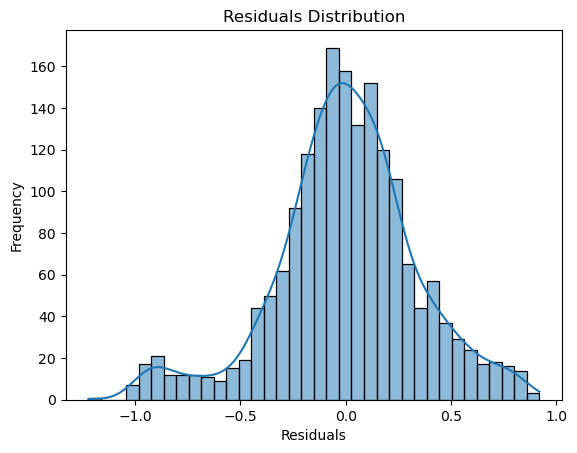

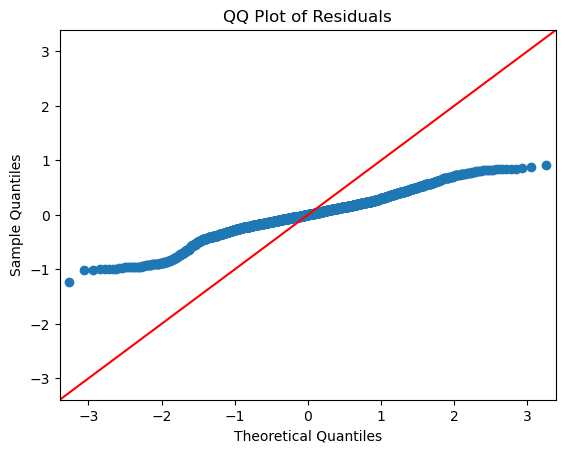

✅ Regression results successfully exported to 'Regression_OLS_Results'


In [21]:
# ------------------------------------------
# OLS REGRESSION ANALYSIS
# ------------------------------------------

# ADDITIONAL PARAMETERS
# STEP 1 - Interaction Terms
interaction_terms = [] # ('Starting_INT','Starting_Employment_ln') ('Starting_INT','Starting_Size_ln') 'HGX_Increased Export Intensity' ('Starting_INT','Foreign')

# STEP 2 - Dummy controlset-up

# OPTION A: MANUAL REFERENCE (full control)
reference_dict = {
    'P/F': 'P',
    'Sector': 'budownictwo',
'HGX': 'Decreased Export Intensity'} #     'HGX': 'Decreased Export Intensity',

# OPTION B: AUTOMATIC REFERENCE (first category found) – use only if needed
# reference_dict = {
#     var: df_clean[var].dropna().unique()[0] for var in categorical_vars
# }

rename_dict = {
    'P/F_F': 'Foreign',
}

# Step 2: Create all dummies
X_categorical = pd.get_dummies(df_clean[categorical_vars])

# Step 3: Drop reference dummy columns
for var, ref in reference_dict.items():
    col_to_drop = f"{var}_{ref}"
    if col_to_drop in X_categorical.columns:
        X_categorical = X_categorical.drop(columns=col_to_drop)

# Step 4: Rename columns for clarity
X_categorical = X_categorical.rename(columns=rename_dict)

# Print to verify the available dummy columns
print("\n✅ Available Dummy Variables:")
print(X_categorical.columns)

# STEP 5: STANDARDIZE NUMERIC VARIABLES
X_numeric = pd.DataFrame(
    StandardScaler().fit_transform(df_clean[numeric_features]),
    columns=numeric_features,
    index=df_clean.index
)

# STEP5 WITHOUT STANDARISATION X_numeric = df_clean[numeric_features].copy()

# STEP 5B: CLEAN COLUMN NAMES TO PREVENT HIDDEN ERRORS
X_numeric.columns = X_numeric.columns.str.strip()
X_categorical.columns = X_categorical.columns.str.strip()

# STEP 5C: DEFINE INTERACTION TERMS

interaction_terms = [(t1.strip(), t2.strip()) for t1, t2 in interaction_terms]

# STEP 5D: ADD INTERACTION TERMS WITH DIAGNOSTICS
for term1, term2 in interaction_terms:
    found_1_num = term1 in X_numeric.columns
    found_2_num = term2 in X_numeric.columns
    found_1_cat = term1 in X_categorical.columns
    found_2_cat = term2 in X_categorical.columns

    print(f"\n🔍 Trying to add interaction: {term1} * {term2}")
    print(f"  - {term1} in X_numeric: {found_1_num}")
    print(f"  - {term2} in X_numeric: {found_2_num}")
    print(f"  - {term1} in X_categorical: {found_1_cat}")
    print(f"  - {term2} in X_categorical: {found_2_cat}")

    # Get the variables
    if found_1_num:
        col1 = X_numeric[term1]
    elif found_1_cat:
        col1 = X_categorical[term1]
    else:
        print(f"⚠️ {term1} not found.")
        continue

    if found_2_num:
        col2 = X_numeric[term2]
    elif found_2_cat:
        col2 = X_categorical[term2]
    else:
        print(f"⚠️ {term2} not found.")
        continue

    # Compute interaction
    interaction_name = f"{term1}_Mult_{term2}"
    interaction_column = col1 * col2

    # Store in correct matrix
    if found_1_num and found_2_num:
        X_numeric[interaction_name] = interaction_column
        print(f"✅ Added to X_numeric: {interaction_name}")
    else:
        X_categorical[interaction_name] = interaction_column
        print(f"✅ Added to X_categorical: {interaction_name}")


# STEP 6: COMBINE FEATURES AND ADD CONSTANT
X_full = pd.concat([X_numeric, X_categorical], axis=1)
X_full = sm.add_constant(X_full).astype(float)

# STEP 7: DEFINE TARGET
y = df_clean[target_variable]

# STEP 8: FIT OLS REGRESSION MODEL
model = sm.OLS(y, X_full).fit()

# Extract coefficients as dataframe
coeff_df = pd.DataFrame({
    "Variable": model.params.index,
    "Coef": model.params.values,
    "Std Err": model.bse.values,
    "t": model.tvalues.values,
    "P>|t|": model.pvalues.values,
    "[0.025": model.conf_int()[0].values,
    "0.975]": model.conf_int()[1].values
})

# Display the full model summary
display(model.summary())

# STEP 8B: EXTRACT REGRESSION SUMMARY STATISTICS
summary_stats = {
    "Statistic": ["R-squared", "Adj. R-squared", "F-statistic", "Prob (F-statistic)", 
                  "Log-Likelihood", "AIC", "BIC", "No. Observations", "DF Residuals", "DF Model"],
    "Value": [
        model.rsquared,
        model.rsquared_adj,
        model.fvalue,
        model.f_pvalue,
        model.llf,
        model.aic,
        model.bic,
        model.nobs,
        model.df_resid,
        model.df_model
    ]
}
summary_df = pd.DataFrame(summary_stats)

# STEP 9: NORMALITY TESTS
residuals = model.resid.replace([np.inf, -np.inf], np.nan).dropna()
shapiro_test = shapiro(residuals)
jb_test = jarque_bera(residuals)

residual_stats = pd.DataFrame({
    "Test": ["Shapiro-Wilk", "Jarque-Bera"],
    "Statistic": [shapiro_test.statistic, jb_test.statistic],
    "p-value": [shapiro_test.pvalue, jb_test.pvalue]
})

print("\n🔍 Shapiro-Wilk Test (normality):")
print(f"  Statistic = {shapiro_test.statistic:.4f}")
print(f"  p-value   = {shapiro_test.pvalue:.4f}")

print("\n📦 Jarque-Bera Test (skew + kurtosis):")
print(f"  Statistic = {jb_test.statistic:.4f}")
print(f"  p-value   = {jb_test.pvalue:.4f}")

# STEP 10: CALCULATE VIF TO CHECK MULTICOLLINEARITY
vif_data = pd.DataFrame({
    "Variable": X_full.columns,
    "VIF": [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])]
})
display(vif_data)

# STEP 11: RESIDUALS DISTRIBUTION PLOT
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# STEP 12: QQ PLOT
sm.qqplot(residuals, line='45')
plt.title("QQ Plot of Residuals")
plt.show()

from datetime import datetime

now = datetime.now()

# ---------- TARGET OUTLIER SUMMARY ----------
# Record outlier method and number of affected observations (TARGET)
if target_outlier_method == 'winsor':
    flag_col = f"{target_raw}_was_winsorized"
    outlier_count = int(df_clean[flag_col].sum()) if flag_col in df_clean.columns else 0
    outlier_description = f"TARGET: WINSOR (percentile = {target_percentile})"
    outlier_note = f"{outlier_count} companies winsorised"

elif target_outlier_method == 'trim':
    original_n = df_clean_before_outliers.shape[0]
    trimmed_n  = df_clean.shape[0]
    outlier_count = original_n - trimmed_n
    outlier_description = f"TARGET: TRIM (percentile = {target_percentile})"
    outlier_note = f"{outlier_count} companies trimmed"

else:  # 'none'
    outlier_count = 0
    outlier_description = "TARGET: none"
    outlier_note = "no outlier handling on target"


# ---------- FEATURE OUTLIER SUMMARY ----------
# assumes you have numeric_features_raw with original names
if feature_outlier_method == 'winsor':
    feature_outlier_count = 0
    for col in numeric_features_raw:
        flag_col = f"{col}_was_winsorized"
        if flag_col in df_clean.columns:
            feature_outlier_count += int(df_clean[flag_col].sum())
elif feature_outlier_method == 'trim':
    original_n = df_clean_before_outliers.shape[0]
    trimmed_n  = df_clean.shape[0]
    feature_outlier_count = original_n - trimmed_n
else:  # 'none'
    feature_outlier_count = 0

feature_summary = f"{feature_outlier_method} (p={feature_percentile})"
feature_note    = f"{feature_outlier_count} observations affected"


# ---------- METADATA TABLE ----------
metadata_items = [
    ("Dep. Variable", model.model.endog_names),
    ("Model", type(model.model).__name__),
    ("Method", "Least Squares"),
    ("Date", now.strftime("%Y-%m-%d")),
    ("Time", now.strftime("%H:%M:%S")),
    ("No. Observations", model.nobs),
    ("Df Residuals", model.df_resid),
    ("Df Model", model.df_model),
    ("Covariance Type", model.cov_type),
    ("Outlier Handling", outlier_description),
    ("Affected Companies", outlier_note),
]

# Add features info
metadata_items.extend([
    ("Feature Outlier Handling", feature_summary),
    ("Feature Affected", feature_note),
])


# Convert summary stats to tuples
summary_items = list(zip(summary_df["Statistic"], summary_df["Value"]))

# Combine both into one list
combined_summary = metadata_items + summary_items

# Create DataFrame
combined_df = pd.DataFrame(combined_summary, columns=["Item", "Value"])

# EXPORT TO EXCEL
with pd.ExcelWriter("Results/Regression_OLS_Results.xlsx") as writer:
    combined_df.to_excel(writer, sheet_name="Model_Summary", index=False)
    coeff_df.to_excel(writer, sheet_name="Model_Coefficients", index=False)
    vif_data.to_excel(writer, sheet_name="VIF", index=False)
    residual_stats.to_excel(writer, sheet_name="Residual_Tests", index=False)

print("✅ Regression results successfully exported to 'Regression_OLS_Results'")

In [22]:
# ------------------------------------------
# ORDERED LOGIT (compact summary version)
# ------------------------------------------

# 1) Prepare X and ordered target as before
Xo = X_full.drop(columns=['const'], errors='ignore').copy()

_num_prefix = re.compile(r'^\s*(-?\d+)\s*[.)-]*\s*')
def _extract_prefix_int(label):
    s = str(label)
    m = _num_prefix.match(s)
    return int(m.group(1)) if m else None

def _order_by_numeric_prefix(series: pd.Series) -> pd.Series:
    s = series.astype(object)
    # try numeric ordering first
    try:
        as_num = pd.to_numeric(s, errors='raise')
        cats = sorted(pd.unique(as_num))
        return pd.Series(pd.Categorical(as_num, categories=cats, ordered=True), index=series.index)
    except Exception:
        pass
    # fallback: order by numeric prefix if present, else alphabetical
    cats = pd.Index(pd.unique(s.dropna()))
    pairs = [(_extract_prefix_int(c), c) for c in cats]
    if any(p[0] is not None for p in pairs):
        ordered = [c for _, c in sorted(pairs, key=lambda t: (t[0] is None, t[0], str(t[1])))]
    else:
        ordered = sorted([str(c) for c in cats])
    return pd.Series(pd.Categorical(s, categories=ordered, ordered=True), index=series.index)

yo_series = _order_by_numeric_prefix(df_clean['SGrowth_NR'])

# Ensure numeric, aligned and clean
Xo = Xo.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
mask = Xo.notna().all(axis=1) & (~yo_series.isna())
Xo, yo_series = Xo.loc[mask].astype('float64'), yo_series.loc[mask]

# 2) Fit model
ord_mod = OrderedModel(yo_series, Xo, distr='logit')
ord_res = ord_mod.fit(method='bfgs', maxiter=1000, disp=False)

# 3) Tidy outputs (predictors)
ord_coef_df = pd.DataFrame({
    'coef':   ord_res.params.reindex(Xo.columns),
    'std_err': ord_res.bse.reindex(Xo.columns),
    'z':       ord_res.tvalues.reindex(Xo.columns),
    'p>|z|':   ord_res.pvalues.reindex(Xo.columns),
}).join(
    ord_res.conf_int().reindex(Xo.columns).rename(columns={0: 'CI_low', 1: 'CI_high'})
)

# 3a) add odds ratios
ord_coef_df['odds_ratio'] = np.exp(ord_coef_df['coef'])

# 4) Thresholds
cut_index = [i for i in ord_res.params.index if i not in Xo.columns]
ord_cuts_df = pd.DataFrame({
    'threshold': ord_res.params.reindex(cut_index),
    'std_err':   ord_res.bse.reindex(cut_index),
    'z':         ord_res.tvalues.reindex(cut_index),
    'p>|z|':     ord_res.pvalues.reindex(cut_index),
}).join(
    ord_res.conf_int().reindex(cut_index).rename(columns={0: 'CI_low', 1: 'CI_high'})
)

# 5) Predicted probabilities (aggregate only)
ord_pred_probs = ord_res.model.predict(ord_res.params, exog=Xo)
pred_probs_df = pd.DataFrame(ord_pred_probs, columns=yo_series.cat.categories)

summary_rows = []
for cat in yo_series.cat.categories:
    observed_pct = (yo_series == cat).mean() * 100
    predicted_pct = (pred_probs_df.idxmax(axis=1) == cat).mean() * 100
    avg_prob = pred_probs_df[cat].mean()
    summary_rows.append({
        'Category': cat,
        'Observed %': round(observed_pct, 2),
        'Predicted %': round(predicted_pct, 2),
        'Average P(Category)': round(avg_prob, 3)
    })

summary_df = pd.DataFrame(summary_rows)

# 6) Model fit statistics
fit_summary = pd.DataFrame([
    ["Log-Likelihood",               ord_res.llf],
    ["Pseudo R-squared (McFadden)",  1 - (ord_res.llf / ord_res.llnull)],
    ["AIC",                          ord_res.aic],
    ["BIC",                          ord_res.bic],
    ["No. Observations",             Xo.shape[0]],
], columns=["Statistic", "Value"])

# 7) Export to Excel
out_path = "Results/Regression_Ordered_Results.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl", mode="w") as writer:
    ord_coef_df.to_excel(writer, sheet_name="Ordered_Logit_Coeff")          # now includes odds_ratio
    ord_cuts_df.to_excel(writer, sheet_name="Ordered_Logit_Thresholds")
    summary_df.to_excel(writer, sheet_name="Ordered_Logit_Summary", index=False)
    fit_summary.to_excel(writer, sheet_name="Ordered_Logit_ModelFit", index=False)

# 8) DISPLAY RESULTS
print("\n✅ Ordered Logit Model Fitted Successfully!\n")

print("📊 Coefficients (predictors) + odds ratios:")
display(ord_coef_df.round(4))

print("⚙️ Threshold (cut points) estimates:")
display(ord_cuts_df.round(4))

print("📈 Model Fit Statistics:")
display(fit_summary.round(4))

print("\n🔎 Summary of observed vs predicted category distribution:")
display(summary_df)

print("\n✅ Compact Ordered Logit results exported to 'Results/Regression_Ordered_Results.xlsx'.")



✅ Ordered Logit Model Fitted Successfully!

📊 Coefficients (predictors) + odds ratios:


,coef,std_err,z,p>|z|,CI_low,CI_high,odds_ratio
Starting_Size_ln,"0,05","0,05","1,06","0,29","-0,04","0,14","1,05"
Starting_BS_Strength,"-0,04","0,05","-0,82","0,41","-0,14","0,06","0,96"
Starting_ROS,"0,07","0,05","1,44","0,15","-0,02","0,16","1,07"
Starting_INT,"-0,05","0,05","-1,02","0,31","-0,15","0,05","0,95"
Foreign,"-0,24","0,09","-2,58","0,01","-0,42","-0,06","0,79"
Sector_chemia,"-0,11","0,27","-0,40","0,69","-0,64","0,42","0,90"
Sector_energetyka,"2,35","0,44","5,38","0,00","1,50","3,21","10,50"
Sector_górnictwo i hutnictwo,"-0,55","0,34","-1,61","0,11","-1,22","0,12","0,58"
Sector_handel detaliczny,"-0,07","0,26","-0,28","0,78","-0,57","0,43","0,93"
Sector_handel hurtowy,"0,04","0,18","0,21","0,83","-0,32","0,40","1,04"


⚙️ Threshold (cut points) estimates:


,threshold,std_err,z,p>|z|,CI_low,CI_high
N1/N2,"-0,63","0,14","-4,52","0,00","-0,90","-0,35"
N2/R1,"-0,57","0,06","-9,38","0,00","-0,68","-0,45"
R1/R2,"0,79","0,04","22,35","0,00","0,72","0,86"


📈 Model Fit Statistics:


,Statistic,Value
0,Log-Likelihood,"-2 197,88"
1,Pseudo R-squared (McFadden),"0,02"
2,AIC,"4 439,75"
3,BIC,"4 560,69"
4,No. Observations,"1 803,00"



🔎 Summary of observed vs predicted category distribution:


,Category,Observed %,Predicted %,Average P(Category)
0,N1,"36,99","42,15","0,37"
1,N2,"13,53","0,00","0,14"
2,R1,"39,10","56,35","0,39"
3,R2,"10,37","1,50","0,10"



✅ Compact Ordered Logit results exported to 'Results/Regression_Ordered_Results.xlsx'.


In [23]:
# ------------------------------------------
# ORDERED LOGIT – marginal effects (one block)
# ------------------------------------------

def _logistic_pdf(z):
    ez = np.exp(-z)
    return ez / (1 + ez)**2

# 1) grab stuff from fitted model
betas = ord_res.params.reindex(Xo.columns).values          # (K,)
xb    = np.dot(Xo.values, betas)                           # (N,)

# thresholds (cut points)
cut_index = [i for i in ord_res.params.index if i not in Xo.columns]
cuts = ord_res.params.reindex(cut_index).values            # (J-1,)

cats = list(yo_series.cat.categories)                      # ordered outcome labels
N, K = Xo.shape
J = len(cats)

# 2) f(k - xb) for every obs and every cut
cut_minus_xb = cuts[None, :] - xb[:, None]                 # (N, J-1)
f_vals = _logistic_pdf(cut_minus_xb)                       # (N, J-1)

# 3) average marginal effects
mfx_rows = []
for k, var in enumerate(Xo.columns):
    beta_k = betas[k]
    for j, cat in enumerate(cats):
        if j == 0:
            dP = -beta_k * f_vals[:, 0]
        elif j == J - 1:
            dP = beta_k * f_vals[:, -1]
        else:
            dP = beta_k * (f_vals[:, j-1] - f_vals[:, j])
        ame = dP.mean()
        mfx_rows.append({
            "Outcome": cat,
            "Variable": var,
            "dydx": ame
        })

ord_mfx_df = pd.DataFrame(mfx_rows)

# 4) wide/tidy version, but keep the original order
mfx_wide = (
    ord_mfx_df
    .pivot(index="Variable", columns="Outcome", values="dydx")
)

# reorder rows to match Xo.columns
mfx_wide = mfx_wide.reindex(index=Xo.columns)

# reorder columns to match the ordered categories
mfx_wide = mfx_wide[cats]

mfx_wide = mfx_wide.reset_index().round(4)

# 5) write to Excel
out_path = "Results/Regression_Ordered_Results.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    ord_mfx_df.to_excel(writer, sheet_name="Ordered_Logit_MargEffects", index=False)
    mfx_wide.to_excel(writer, sheet_name="Ordered_Logit_MargEffects_Tidy", index=False)

# 6) show tidy in notebook
print("\n📐 Ordered Logit – marginal effects (tidy):")
display(mfx_wide.head(40))
print(f"\n✅ Marginal effects (long + tidy) added to {out_path}.")



📐 Ordered Logit – marginal effects (tidy):


Outcome,index,N1,N2,R1,R2
0,Starting_Size_ln,"-0,01","-0,00","0,00","0,01"
1,Starting_BS_Strength,"0,01","0,00","-0,00","-0,01"
2,Starting_ROS,"-0,02","-0,00","0,00","0,01"
3,Starting_INT,"0,01","0,00","-0,00","-0,01"
4,Foreign,"0,05","0,00","-0,01","-0,05"
5,Sector_chemia,"0,02","0,00","-0,00","-0,02"
6,Sector_energetyka,"-0,53","-0,01","0,07","0,48"
7,Sector_górnictwo i hutnictwo,"0,13","0,00","-0,02","-0,11"
8,Sector_handel detaliczny,"0,02","0,00","-0,00","-0,01"
9,Sector_handel hurtowy,"-0,01","-0,00","0,00","0,01"



✅ Marginal effects (long + tidy) added to Results/Regression_Ordered_Results.xlsx.


In [24]:
# 0) assume you already have:
# ord_res, Xo, yo_series
# and you already built mfx_wide in the previous step

# ------------------------------------------------
# 1. Build main regression table (coef, z, p, odds)
# ------------------------------------------------
var_names = list(Xo.columns)

params = ord_res.params.reindex(var_names)
bse    = ord_res.bse.reindex(var_names)
zvals  = params / bse
pvals  = ord_res.pvalues.reindex(var_names)
odds   = np.exp(params)

main_df = pd.DataFrame({
    "Variable": var_names,
    "coef": params.values,
    "p>|z|": pvals.values,
    "Odds_ratio": odds.values
})

# ------------------------------------------------
# 2. Make sure mfx_wide has a 'Variable' column
# ------------------------------------------------
mfx_wide_named = mfx_wide.copy()

# if your previous code left variables in the index, pull them out
if mfx_wide_named.index.name is not None or "Variable" not in mfx_wide_named.columns:
    mfx_wide_named = mfx_wide_named.reset_index()

# now rename the column that came from the index to 'Variable'
# often after reset_index it's called 'index' or whatever the index name was
if "index" in mfx_wide_named.columns and "Variable" not in mfx_wide_named.columns:
    mfx_wide_named = mfx_wide_named.rename(columns={"index": "Variable"})
elif mfx_wide_named.columns[0] != "Variable":
    # in case the first column is the variable name but has some other label
    mfx_wide_named = mfx_wide_named.rename(columns={mfx_wide_named.columns[0]: "Variable"})

# ------------------------------------------------
# 3. Merge
# ------------------------------------------------
full_table = pd.merge(main_df, mfx_wide_named, on="Variable", how="left")

# ------------------------------------------------
# 4. Round numbers
# ------------------------------------------------
full_table_rounded = full_table.copy()
num_cols = full_table_rounded.select_dtypes(include=["number"]).columns
full_table_rounded[num_cols] = full_table_rounded[num_cols].round(4)

# ------------------------------------------------
# 5. Save
# ------------------------------------------------
out_path = "Results/Regression_Ordered_Results.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    full_table_rounded.to_excel(writer, sheet_name="Ordered_Logit_Full", index=False)

display(full_table_rounded.head(40))
print(f"\n✅ Combined table (coef, z, p, odds, marginal effects) saved to {out_path}.")


,Variable,coef,p>|z|,Odds_ratio,level_0,N1,N2,R1,R2
0,Starting_Size_ln,"0,05","0,29","1,05",0,"-0,01","-0,00","0,00","0,01"
1,Starting_BS_Strength,"-0,04","0,41","0,96",1,"0,01","0,00","-0,00","-0,01"
2,Starting_ROS,"0,07","0,15","1,07",2,"-0,02","-0,00","0,00","0,01"
3,Starting_INT,"-0,05","0,31","0,95",3,"0,01","0,00","-0,00","-0,01"
4,Foreign,"-0,24","0,01","0,79",4,"0,05","0,00","-0,01","-0,05"
5,Sector_chemia,"-0,11","0,69","0,90",5,"0,02","0,00","-0,00","-0,02"
6,Sector_energetyka,"2,35","0,00","10,50",6,"-0,53","-0,01","0,07","0,48"
7,Sector_górnictwo i hutnictwo,"-0,55","0,11","0,58",7,"0,13","0,00","-0,02","-0,11"
8,Sector_handel detaliczny,"-0,07","0,78","0,93",8,"0,02","0,00","-0,00","-0,01"
9,Sector_handel hurtowy,"0,04","0,83","1,04",9,"-0,01","-0,00","0,00","0,01"



✅ Combined table (coef, z, p, odds, marginal effects) saved to Results/Regression_Ordered_Results.xlsx.


In [25]:
import numpy as np
import pandas as pd

# ------------------------------------------------
# ORDERED LOGIT: full table (model + marginal effects)
# requires: ord_res, Xo, yo_series (yo_series must be categorical ordered)
# ------------------------------------------------

def _logistic_pdf(z):
    ez = np.exp(-z)
    return ez / (1 + ez)**2

# 1. model parts
betas = ord_res.params.reindex(Xo.columns).values           # (K,)
xb    = np.dot(Xo.values, betas)                            # (N,)

# cut points (all params that are NOT in Xo)
cut_index = [i for i in ord_res.params.index if i not in Xo.columns]
cuts = ord_res.params.reindex(cut_index).values             # (J-1,)

# outcome levels
cats = list(yo_series.cat.categories)   # e.g. ['0.Stressed', '1.Declining', ...]
N, K = Xo.shape
J = len(cats)

# 2. pdf values
cut_minus_xb = cuts[None, :] - xb[:, None]                  # (N, J-1)
f_vals = _logistic_pdf(cut_minus_xb)                        # (N, J-1)

# 3. build marginal effects (long)
mfx_rows = []
for k, var in enumerate(Xo.columns):
    beta_k = betas[k]
    for j, cat in enumerate(cats):
        if j == 0:
            dP = -beta_k * f_vals[:, 0]
        elif j == J - 1:
            dP = beta_k * f_vals[:, -1]
        else:
            dP = beta_k * (f_vals[:, j-1] - f_vals[:, j])
        mfx_rows.append(
            {"Variable": str(var), "Outcome": str(cat), "dydx": float(dP.mean())}
        )

ord_mfx_df = pd.DataFrame(mfx_rows)

# safety check
if "Variable" not in ord_mfx_df.columns or "Outcome" not in ord_mfx_df.columns:
    raise ValueError(f"Unexpected columns in marginal effects: {ord_mfx_df.columns}")

# 4. pivot to wide, keep order
mfx_wide = (
    ord_mfx_df
    .pivot_table(index="Variable", columns="Outcome", values="dydx", aggfunc="first")
)

# force row order to match model, and column order to match categories
mfx_wide = mfx_wide.reindex(index=[str(v) for v in Xo.columns])
mfx_wide = mfx_wide.reindex(columns=[str(c) for c in cats])

# bring index out
mfx_wide = mfx_wide.reset_index()

# 5. main model table
var_names = [str(v) for v in Xo.columns]

params = ord_res.params.reindex(var_names)
bse    = ord_res.bse.reindex(var_names)
zvals  = params / bse
pvals  = ord_res.pvalues.reindex(var_names)
odds   = np.exp(params)

main_df = pd.DataFrame({
    "Variable": var_names,
    "coef": params.values,
    "z": zvals.values,
    "p>|z|": pvals.values,
    "Odds_ratio": odds.values
})

# 6. merge
# make sure both sides are string
main_df["Variable"] = main_df["Variable"].astype(str)
mfx_wide["Variable"] = mfx_wide["Variable"].astype(str)

full_table = pd.merge(main_df, mfx_wide, on="Variable", how="left")

# 7. round numeric cols
num_cols = full_table.select_dtypes(include=["number"]).columns
full_table[num_cols] = full_table[num_cols].round(4)

# 8. export
out_path = "Results/Regression_Ordered_Results.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    ord_mfx_df.to_excel(writer, sheet_name="Ordered_Logit_MargEffects_Long", index=False)
    mfx_wide.to_excel(writer, sheet_name="Ordered_Logit_MargEffects_Tidy", index=False)
    full_table.to_excel(writer, sheet_name="Ordered_Logit_Full", index=False)

display(full_table.head(40))
print(f"\n✅ Combined ordered logit table saved to {out_path}.")


,Variable,coef,z,p>|z|,Odds_ratio,N1,N2,R1,R2
0,Starting_Size_ln,"0,05","1,06","0,29","1,05","-0,01","-0,00","0,00","0,01"
1,Starting_BS_Strength,"-0,04","-0,82","0,41","0,96","0,01","0,00","-0,00","-0,01"
2,Starting_ROS,"0,07","1,44","0,15","1,07","-0,02","-0,00","0,00","0,01"
3,Starting_INT,"-0,05","-1,02","0,31","0,95","0,01","0,00","-0,00","-0,01"
4,Foreign,"-0,24","-2,58","0,01","0,79","0,05","0,00","-0,01","-0,05"
5,Sector_chemia,"-0,11","-0,40","0,69","0,90","0,02","0,00","-0,00","-0,02"
6,Sector_energetyka,"2,35","5,38","0,00","10,50","-0,53","-0,01","0,07","0,48"
7,Sector_górnictwo i hutnictwo,"-0,55","-1,61","0,11","0,58","0,13","0,00","-0,02","-0,11"
8,Sector_handel detaliczny,"-0,07","-0,28","0,78","0,93","0,02","0,00","-0,00","-0,01"
9,Sector_handel hurtowy,"0,04","0,21","0,83","1,04","-0,01","-0,00","0,00","0,01"



✅ Combined ordered logit table saved to Results/Regression_Ordered_Results.xlsx.


In [26]:
# ------------------------------------------
# CORRELATION ANALYSIS (BASED ON MODEL MATRIX)
# ------------------------------------------

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from openpyxl import Workbook

# 1. Build a dataframe with target + all regressors (except constant)
corr_df = pd.concat(
    [
        pd.Series(y, name=target_variable),              # target
        X_full.drop(columns=["const"], errors="ignore")  # all predictors
    ],
    axis=1
)

# 2. Correlation matrix (Pearson)
correlation_matrix = corr_df.corr()

# 3. Make sure target is first (rows & columns)
cols = list(correlation_matrix.columns)
if target_variable in cols:
    cols.insert(0, cols.pop(cols.index(target_variable)))
    correlation_matrix = correlation_matrix.reindex(index=cols, columns=cols)

# ---------------------------------------------------------
# 4. P-VALUE MATRIX FOR CORRELATIONS (PAIRWISE PEARSON)
# ---------------------------------------------------------

pval_matrix = pd.DataFrame(
    np.nan,
    columns=correlation_matrix.columns,
    index=correlation_matrix.index
)

for r in correlation_matrix.columns:
    for c in correlation_matrix.columns:
        if r == c:
            # no p-value for self-correlation
            pval_matrix.loc[r, c] = np.nan
        else:
            # align non-missing values for both variables
            x = corr_df[r]
            y = corr_df[c]
            mask = x.notna() & y.notna()
            if mask.sum() >= 2:
                _, p = pearsonr(x[mask], y[mask])
                pval_matrix.loc[r, c] = p
            else:
                pval_matrix.loc[r, c] = np.nan

# Reorder p-value matrix same as correlation matrix
pval_matrix = pval_matrix.reindex(index=cols, columns=cols)

# ---------------------------------------------------------
# 5. FLATTEN, CLEAN AND GET TOP 10 CORRELATIONS (WITH P)
# ---------------------------------------------------------

# Flatten correlation matrix
correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]

# Flatten p-value matrix and merge
pval_pairs = pval_matrix.unstack().reset_index()
pval_pairs.columns = ["Variable 1", "Variable 2", "P_value"]

# Merge correlation and p-value info
correlation_pairs = correlation_pairs.merge(
    pval_pairs,
    on=["Variable 1", "Variable 2"],
    how="left"
)

# Remove self-correlations
correlation_pairs = correlation_pairs[
    correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]
]

# Remove duplicate pairs (A-B vs B-A)
correlation_pairs["Pair"] = correlation_pairs.apply(
    lambda row: "-".join(sorted([row["Variable 1"], row["Variable 2"]])),
    axis=1
)
correlation_pairs = correlation_pairs.drop_duplicates(subset="Pair").drop(columns=["Pair"])

# Sort by absolute correlation value and take top 10
top_10_correlations = correlation_pairs.reindex(
    correlation_pairs["Correlation"].abs().sort_values(ascending=False).index
).head(10)

# ---------------------------------------------------------
# 6. EXPORT TO EXCEL
# ---------------------------------------------------------

output_path = "Results/Correlation_Matrix.xlsx"

# Create a brand new workbook (overwrite if exists)
wb = Workbook()
wb.save(output_path)

with pd.ExcelWriter(output_path, engine="openpyxl", mode="w") as writer:
    correlation_matrix.to_excel(
        writer,
        sheet_name="Correlation_Matrix",
        float_format="%.4f"
    )
    pval_matrix.to_excel(
        writer,
        sheet_name="Correlation_pvalues",
        float_format="%.6f"
    )
    top_10_correlations.to_excel(
        writer,
        sheet_name="Top_10_Correlations",
        index=False
    )

print("New file 'Correlation_Matrix.xlsx' created successfully.")

#Optional
display(correlation_matrix)
display(pval_matrix)
display(top_10_correlations)

New file 'Correlation_Matrix.xlsx' created successfully.


,LSGrowth_2023_2019_win,Starting_Size_ln,Starting_BS_Strength,Starting_ROS,Starting_INT,Foreign,Sector_chemia,Sector_energetyka,Sector_górnictwo i hutnictwo,Sector_handel detaliczny,Sector_handel hurtowy,"Sector_media, telekomunkacja, IT",Sector_motoryzacja,Sector_ochrona zdrowia i farmacja,Sector_paliwa,Sector_produkcja,Sector_transport,Sector_usługi,Sector_żywność,HGX_Increased Export Intensity
LSGrowth_2023_2019_win,"1,00","0,05","0,07","0,07","-0,05","-0,06","-0,01","0,13","-0,00","0,01","-0,05","-0,01","-0,01","0,01","-0,02","-0,05","0,00","0,01","0,12","0,06"
Starting_Size_ln,"0,05","1,00","-0,05","-0,04","-0,01","0,10","0,01","0,11","0,05","0,14","-0,06","0,01","0,07","0,01","0,03","-0,08","0,00","-0,02","0,01","0,02"
Starting_BS_Strength,"0,07","-0,05","1,00","0,38","0,20","0,06","0,02","-0,01","0,04","-0,07","-0,09","-0,02","-0,10","-0,04","0,01","0,20","-0,09","-0,06","0,10","0,05"
Starting_ROS,"0,07","-0,04","0,38","1,00","0,07","0,08","0,00","-0,07","-0,01","-0,02","-0,08","0,04","-0,06","-0,03","-0,05","0,09","0,04","-0,02","-0,02","0,02"
Starting_INT,"-0,05","-0,01","0,20","0,07","1,00","0,30","-0,01","-0,09","0,03","-0,14","-0,14","-0,01","0,20","-0,06","-0,13","0,29","0,00","-0,10","0,00","0,07"
Foreign,"-0,06","0,10","0,06","0,08","0,30","1,00","-0,06","-0,09","-0,04","0,03","-0,05","0,04","0,11","0,04","-0,08","0,10","-0,00","-0,04","-0,04","0,10"
Sector_chemia,"-0,01","0,01","0,02","0,00","-0,01","-0,06","1,00","-0,02","-0,02","-0,04","-0,06","-0,04","-0,07","-0,04","-0,03","-0,09","-0,04","-0,04","-0,06","0,05"
Sector_energetyka,"0,13","0,11","-0,01","-0,07","-0,09","-0,09","-0,02","1,00","-0,02","-0,03","-0,04","-0,03","-0,05","-0,03","-0,02","-0,06","-0,03","-0,03","-0,04","-0,05"
Sector_górnictwo i hutnictwo,"-0,00","0,05","0,04","-0,01","0,03","-0,04","-0,02","-0,02","1,00","-0,03","-0,05","-0,03","-0,05","-0,03","-0,03","-0,07","-0,03","-0,03","-0,05","-0,01"
Sector_handel detaliczny,"0,01","0,14","-0,07","-0,02","-0,14","0,03","-0,04","-0,03","-0,03","1,00","-0,07","-0,05","-0,08","-0,04","-0,04","-0,10","-0,05","-0,05","-0,07","-0,02"


,LSGrowth_2023_2019_win,Starting_Size_ln,Starting_BS_Strength,Starting_ROS,Starting_INT,Foreign,Sector_chemia,Sector_energetyka,Sector_górnictwo i hutnictwo,Sector_handel detaliczny,Sector_handel hurtowy,"Sector_media, telekomunkacja, IT",Sector_motoryzacja,Sector_ochrona zdrowia i farmacja,Sector_paliwa,Sector_produkcja,Sector_transport,Sector_usługi,Sector_żywność,HGX_Increased Export Intensity
LSGrowth_2023_2019_win,NaN,"0,03","0,00","0,00","0,02","0,01","0,54","0,00","0,91","0,63","0,03","0,77","0,63","0,58","0,50","0,03","0,88","0,79","0,00","0,01"
Starting_Size_ln,"0,03",NaN,"0,04","0,09","0,57","0,00","0,66","0,00","0,02","0,00","0,01","0,66","0,00","0,72","0,17","0,00","0,91","0,37","0,79","0,48"
Starting_BS_Strength,"0,00","0,04",NaN,"0,00","0,00","0,01","0,42","0,73","0,06","0,01","0,00","0,41","0,00","0,09","0,79","0,00","0,00","0,01","0,00","0,03"
Starting_ROS,"0,00","0,09","0,00",NaN,"0,00","0,00","0,83","0,00","0,70","0,46","0,00","0,06","0,01","0,16","0,02","0,00","0,12","0,42","0,35","0,30"
Starting_INT,"0,02","0,57","0,00","0,00",NaN,"0,00","0,79","0,00","0,21","0,00","0,00","0,53","0,00","0,01","0,00","0,00","0,92","0,00","0,97","0,00"
Foreign,"0,01","0,00","0,01","0,00","0,00",NaN,"0,01","0,00","0,12","0,18","0,04","0,10","0,00","0,10","0,00","0,00","0,84","0,10","0,13","0,00"
Sector_chemia,"0,54","0,66","0,42","0,83","0,79","0,01",NaN,"0,34","0,29","0,12","0,01","0,06","0,00","0,09","0,15","0,00","0,07","0,06","0,01","0,02"
Sector_energetyka,"0,00","0,00","0,73","0,00","0,00","0,00","0,34",NaN,"0,46","0,28","0,08","0,19","0,04","0,24","0,31","0,01","0,20","0,19","0,06","0,04"
Sector_górnictwo i hutnictwo,"0,91","0,02","0,06","0,70","0,21","0,12","0,29","0,46",NaN,"0,23","0,05","0,15","0,03","0,19","0,26","0,00","0,16","0,15","0,04","0,80"
Sector_handel detaliczny,"0,63","0,00","0,01","0,46","0,00","0,18","0,12","0,28","0,23",NaN,"0,00","0,04","0,00","0,06","0,10","0,00","0,04","0,04","0,00","0,37"


,Variable 1,Variable 2,Correlation,P_value
43,Starting_BS_Strength,Starting_ROS,"0,38","0,00"
85,Starting_INT,Foreign,"0,30","0,00"
95,Starting_INT,Sector_produkcja,"0,29","0,00"
55,Starting_BS_Strength,Sector_produkcja,"0,20","0,00"
44,Starting_BS_Strength,Starting_INT,"0,20","0,00"
92,Starting_INT,Sector_motoryzacja,"0,20","0,00"
255,Sector_motoryzacja,Sector_produkcja,"-0,19","0,00"
318,Sector_produkcja,Sector_żywność,"-0,17","0,00"
215,Sector_handel hurtowy,Sector_produkcja,"-0,17","0,00"
90,Starting_INT,Sector_handel hurtowy,"-0,14","0,00"


In [27]:
# ------------------------------------------
# CORRELATION ANALYSIS
# ------------------------------------------


# Exclude "Sector" from the list of categorical variables
categorical_vars_filtered = [var for var in categorical_vars if var != 'Sector']

# Combine numeric and filtered categorical variables
df_combined = pd.get_dummies(
    df_clean[numeric_features + categorical_vars_filtered + [target_variable]],
    drop_first=True
)
# Move the target column to the first position
cols = list(df_combined.columns)
if target_variable in cols:
    cols.insert(0, cols.pop(cols.index(target_variable)))
df_combined = df_combined[cols]

# Calculate the correlation matrix
correlation_matrix = df_combined.corr()

# Reorder the rows as well to place target at the top
correlation_matrix = correlation_matrix.reindex(index=cols, columns=cols)

# Display the correlation matrix
display(correlation_matrix)

# Flatten the correlation matrix and remove self-correlations
correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]

# Remove duplicate pairs (A-B and B-A)
correlation_pairs["Pair"] = correlation_pairs.apply(
    lambda row: "-".join(sorted([row["Variable 1"], row["Variable 2"]])), axis=1
)
correlation_pairs.drop_duplicates(subset="Pair", inplace=True)
correlation_pairs.drop(columns=["Pair"], inplace=True)

# Remove self-correlations
correlation_pairs = correlation_pairs[correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]]

# Sort by absolute correlation value
top_10_correlations = correlation_pairs.reindex(
    correlation_pairs.Correlation.abs().sort_values(ascending=False).index
).head(10)


display(top_10_correlations)

from openpyxl import load_workbook
import pandas as pd

output_path = "Results/Regression_OLS_Results.xlsx"

# Make sure the file exists first
book = load_workbook(output_path)

with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    # Just use the context manager, no need to set writer.book anymore
    correlation_matrix.to_excel(writer, sheet_name="Correlation_Matrix", float_format="%.4f")
    top_10_correlations.to_excel(writer, sheet_name="Top_10_Correlations", index=False)

print("Sheets added to 'Regression_OLS_Results.xlsx' successfully!")

,LSGrowth_2023_2019_win,Starting_Size_ln,Starting_BS_Strength,Starting_ROS,Starting_INT,P/F_P,HGX_Increased Export Intensity
LSGrowth_2023_2019_win,"1,00","0,05","0,07","0,07","-0,05","0,06","0,06"
Starting_Size_ln,"0,05","1,00","-0,05","-0,04","-0,01","-0,10","0,02"
Starting_BS_Strength,"0,07","-0,05","1,00","0,38","0,20","-0,06","0,05"
Starting_ROS,"0,07","-0,04","0,38","1,00","0,07","-0,08","0,02"
Starting_INT,"-0,05","-0,01","0,20","0,07","1,00","-0,30","0,07"
P/F_P,"0,06","-0,10","-0,06","-0,08","-0,30","1,00","-0,10"
HGX_Increased Export Intensity,"0,06","0,02","0,05","0,02","0,07","-0,10","1,00"


,Variable 1,Variable 2,Correlation
17,Starting_BS_Strength,Starting_ROS,"0,38"
33,Starting_INT,P/F_P,"-0,30"
18,Starting_BS_Strength,Starting_INT,"0,20"
12,Starting_Size_ln,P/F_P,"-0,10"
41,P/F_P,HGX_Increased Export Intensity,"-0,10"
26,Starting_ROS,P/F_P,"-0,08"
34,Starting_INT,HGX_Increased Export Intensity,"0,07"
2,LSGrowth_2023_2019_win,Starting_BS_Strength,"0,07"
3,LSGrowth_2023_2019_win,Starting_ROS,"0,07"
25,Starting_ROS,Starting_INT,"0,07"


Sheets added to 'Regression_OLS_Results.xlsx' successfully!
